In [3]:
import numpy as np
import pandas as pd
import mdtraj as md

import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
%matplotlib inline
import seaborn as sns

In [4]:
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'sans:italic:bold'
plt.rcParams['mathtext.bf'] = 'sans:bold'

In [5]:
CorrFuncLOC = './Documents/Research/DiffusionTip4pDSoluteSize/'
CorrFuncLoc2 = './Research/LangevinDynamics_RotationalDiffusion/'
ENSEMBLES = ['NVE', 'NVT']
CouplingFrequency = ['CF0-2ps', 'CF2ps', 'CF20ps']
RUNS = ['Run{}'.format(n) for n in range(1,5,1)]
Proteins = ['GB3', 'Ubiquitin']
MINDX = pd.MultiIndex.from_product([Proteins, ENSEMBLES])
MINDX_NVT=pd.MultiIndex.from_product([Proteins, CouplingFrequency])
LocDF_NVE = pd.DataFrame(index=RUNS, columns=MINDX)
LocDF_NVE_R2 = LocDF_NVE.copy()
LocDF_NVE_R3 = LocDF_NVE.copy()
LocDF_NVT = pd.DataFrame(index=RUNS, columns=MINDX_NVT)
FileLocDict = {}

In [6]:
Three2OneAA = {'Ala':'A', 'ALA':'A', 'Arg':'R', 'ARG':'R', 'ASP':'D', 'Asp':'D', 'Asn':'N', 'ASN':'N',
               'Cys':'C', 'CYS':'C', 'Glu':'E', 'GLU':'E', 'Gln':'Q', 'GLN':'Q', 'Gly':'G', 'GLY':'G',
               'His':'H', 'HIS':'H', 'HID':'H', 'Hid':'H', 'HIE':'H', 'Hie':'H', 'ILE':'I', 'Ile':'I',
               'LEU':'L', 'Leu':'L', 'LYS':'K', 'Lys':'K', 'MET':'M', 'Met':'M', 'PHE':'F', 'Phe':'F',
               'Pro':'P', 'PRO':'P', 'Ser':'S', 'SER':'S', 'THR':'T', 'Thr':'T', 'Trp':'W', 'TRP':'W',
               'Tyr':'Y', 'TYR':'Y', 'Val':'V', 'VAL':'V'}

In [7]:
for items, values in LocDF_NVT.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVT.loc[indx, items] = '{}{}/PROD_NVT/{}/{}'.format(CorrFuncLoc2, items[0], items[1], indx)
        
for items, values in LocDF_NVE.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE.loc[indx, items] = '{}{}/PROD_{}/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

for items, values in LocDF_NVE_R2.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE_R2.loc[indx, items] = '{}{}/PROD_{}_Run2/{}'.format(CorrFuncLoc2, items[0], items[1], indx)
        
for items, values in LocDF_NVE_R3.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE_R3.loc[indx, items] = '{}{}/PROD_{}_Run3/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

('GB3', 'CF0-2ps')
('GB3', 'CF2ps')
('GB3', 'CF20ps')
('Ubiquitin', 'CF0-2ps')
('Ubiquitin', 'CF2ps')
('Ubiquitin', 'CF20ps')
('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')
('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')
('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')


In [8]:
GB3Top = md.load_prmtop('{}GB3/GB3_2Na_FF14SB.prmtop'.format(CorrFuncLOC))
GB3CAInd = GB3Top.select('name CA and protein')
GB3CAatom_name = pd.Series(['{}'.format(GB3Top.atom(atmx)) for atmx in GB3CAInd])
GB3atom_df = GB3CAatom_name.str.split('-',expand=True).rename(columns={0:'RESNAME',1:'ATMNAME'})
GB3atom_df['RESNAME'] = GB3atom_df['RESNAME'].apply(lambda rr: '{}'.format(rr[:3] + str(int(rr[3:])+1)))
GB3atom_df['RESID'] = GB3atom_df['RESNAME'].apply(lambda rr: int(rr[3:]))

FileNotFoundError: [Errno 2] No such file or directory: 'E:/Users/Alan/Documents/Research/DiffusionTip4pDSoluteSize/GB3/GB3_2Na_FF14SB.prmtop'

In [12]:
UBQTop = md.load_prmtop('{}Ubiquitin/UBQ_10mMNaCl_FF14SB.prmtop'.format(CorrFuncLoc2))
UBQHInd = UBQTop.select('name CA and protein')
UBQHatom_name = pd.Series(['{}'.format(UBQTop.atom(atmx)) for atmx in UBQHInd])
UBQatom_df = UBQHatom_name.str.split('-',expand=True).rename(columns={0:'RESNAME',1:'ATMNAME'})
UBQatom_df['RESNAME'] = UBQatom_df['RESNAME'].apply(lambda rr: '{}'.format(rr[:3] + str(int(rr[3:])+1)))
UBQatom_df['RESID'] = UBQatom_df['RESNAME'].apply(lambda rr: int(rr[3:]))

In [8]:
## Load the GB3 Full Correlation Function Fits w/ NMR Relaxation:
NMRRelax_FitDF_GB3_NVE = pd.read_csv('{}{}/PROD_NVE/NMRRelax_FitDF_OptSim_Fix2Exp_tm10ns_FixTM_FixFit_LnT_tbm150ps.csv'.format(CorrFuncLoc2, 'GB3'), index_col=0)
NMRRelax_FitDF_GB3_NVT_02ps = pd.read_csv('{}{}/PROD_NVT/CF0-2ps/NMRRelax_FitDF_Fix2Exp_Coupling02ps_tm11ns_FixTM_FixFit_LnT_tbm150ps.csv'.format(CorrFuncLoc2,'GB3'), index_col=0)
NMRRelax_FitDF_GB3_NVT_2ps = pd.read_csv('{}{}/PROD_NVT/CF2ps/NMRRelax_FitDF_Fix2Exp_Coupling2ps_tm16ns_FixTM_FixFit_LnT_tbm150ps.csv'.format(CorrFuncLoc2,'GB3'), index_col=0)
NMRRelax_FitDF_GB3_NVT_20ps = pd.read_csv('{}{}/PROD_NVT/CF20ps/NMRRelax_FitDF_Fix2Exp_Coupling20ps_tm50ns_FixTM_FixFit_LnT_tbm150ps.csv'.format(CorrFuncLoc2,'GB3'), index_col=0)

In [13]:
## Load the GB3 Full Correlation Function Fits w/ NMR Relaxation:
NMRRelax_FitDF_UBQ_NVE = pd.read_csv('{}{}/PROD_NVE/NMRRelax_FitDF_OptSim_Fix2Exp_FixTM12_FixFit_LnT_tbm150ps.csv'.format(CorrFuncLoc2, 'Ubiquitin'), index_col=0)
NMRRelax_FitDF_UBQ_NVT_02ps = pd.read_csv('{}{}/PROD_NVT/CF0-2ps/NMRRelax_Fix2Exp_Coupling02ps_FixTM12_FixFit_LnT_tbm150ps.csv'.format(CorrFuncLoc2,'Ubiquitin'), index_col=0)
NMRRelax_FitDF_UBQ_NVT_2ps = pd.read_csv('{}{}/PROD_NVT/CF2ps/NMRRelax_Fix2Exp_Coupling2ps_FixTM16_FixFit_LnT_tbm150ps.csv'.format(CorrFuncLoc2,'Ubiquitin'), index_col=0)
NMRRelax_FitDF_UBQ_NVT_20ps = pd.read_csv('{}{}/PROD_NVT/CF20ps/NMRRelax_Fix2Exp_Coupling20ps_FixTM50_FixFit_LnT_tbm150ps.csv'.format(CorrFuncLoc2,'Ubiquitin'), index_col=0)

FileNotFoundError: [Errno 2] File b'E:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE/NMRRelax_FitDF_OptSim_Fix2Exp_FixTM12_FixFit_LnT_tbm150ps.csv' does not exist: b'E:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE/NMRRelax_FitDF_OptSim_Fix2Exp_FixTM12_FixFit_LnT_tbm150ps.csv'

In [ ]:
#GB3_SASA_SS = pd.read_csv('{}{}/Analysis/GB3_DSSP_SecondaryStructure_SASA.csv'.format(CorrFuncLoc2,'GB3'), index_col=0)
#GB3_SASA_SS['SS'] = GB3_SASA_SS['SS'].replace({'T':'H'})
#GB3_SASA_SS = GB3_SASA_SS.rename(columns={'Residue':'Resname'})

#UBQ_SASA_SS = pd.read_csv('{}{}/Analysis/UBQ_DSSP_SecondaryStructure_SASA.csv'.format(CorrFuncLoc2,'Ubiquitin'), index_col=0)
#UBQ_SASA_SS['SS'] = GB3_SASA_SS['SS'].replace({'T':'H'})
#UBQ_SASA_SS = GB3_SASA_SS.rename(columns={'Residue':'Resname'})


In [14]:
from matplotlib import cm as cm
## Defining the color map for the dssp plots and secondary structure assignments
spectral_SS = cm.get_cmap('Spectral',3)

spectralW_SS = np.append(spectral_SS(range(3)),[[1., 1. ,1. , 1.]], axis=0)
SS_ColorPalette = {r'$\beta$-Strand':spectralW_SS[0],
                r'Helix':spectralW_SS[1], 'Turn':spectralW_SS[2], 'Coil':spectralW_SS[-1]}

In [15]:
SatCMap_Dark2 = cm.get_cmap('Dark2', 8)

SatCMap_SS = np.append(SatCMap_Dark2(range(8)),[[1., 1. ,1. , 1.]], axis=0)
SatCMap_SS_F3 = [SatCMap_SS[0], SatCMap_SS[3], SatCMap_SS[5]]
SatCMapSS_ColorPalette = {r'$\beta$-Strand':SatCMap_SS[0],
                r'Helix':SatCMap_SS[3], 'Turn':SatCMap_SS[5], 'Coil':SatCMap_SS[-1]}

In [16]:

#SatCMap_SS = np.append(SatCMap_Dark2(range(6)),[[1., 1. ,1. , 1.]], axis=0)
SatCMap_SS_F3 = [SatCMap_SS[3], SatCMap_SS[0], sns.color_palette('Paired')[-2]]
SatYelSS_ColorPalette = {r'$\beta$-Strand':SatCMap_SS[0],
                r'Helix':SatCMap_SS[3], 'Turn':sns.color_palette('Paired')[-2], 'Coil':SatCMap_SS[-1]}

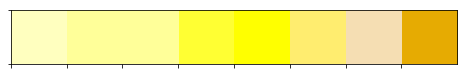

In [17]:
sns.palplot([spectralW_SS[1], sns.color_palette('Paired')[-2], sns.color_palette('Accent')[3], sns.color_palette('Set1')[5], 'yellow', sns.color_palette('Set3')[-1], 'wheat', SatCMap_SS[5]])

## Figure 2:

In [18]:
import statsmodels.api as sm

In [14]:
avg_RotDifDF = pd.read_excel('{}TIP4P-D_Diffusion_Results 12-21.xlsx'.format(CorrFuncLoc2),
              sheet_name='Summary of Results', skiprows=3, header=[0,1])
avg_RotDifDF = avg_RotDifDF.drop(columns=[('Unnamed: 0_level_0', 'Unnamed: 0_level_1'), ('Unnamed: 1_level_0', 'Unnamed: 1_level_1')])

In [15]:
avg_RotDifDF_4Plot = avg_RotDifDF.iloc[:, [0, 1, 2, 4, 6]].dropna()
avg_RotDifDF_4Plot_Scl = avg_RotDifDF.iloc[:, [0, 1, 2, -3, -1]].dropna()


In [16]:
NVT2Exp = sm.OLS(avg_RotDifDF_4Plot.iloc[:,4].values, avg_RotDifDF_4Plot.iloc[:,2].values)
NVT2Exp_fit = NVT2Exp.fit()
sNVT2Exp = sm.OLS(avg_RotDifDF_4Plot_Scl.iloc[:,-1].values, avg_RotDifDF_4Plot.iloc[:,2].values)
sNVT2Exp_fit = sNVT2Exp.fit()

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.


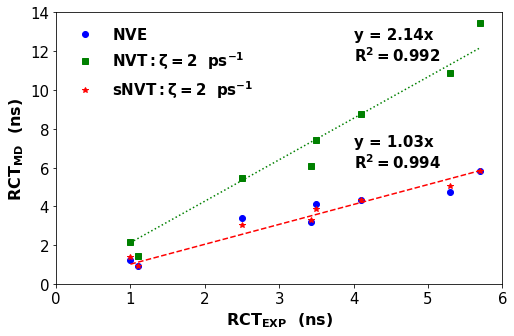

In [17]:
fig_avgRotCorr = plt.figure(3101, figsize=(8,5))
axTcorr = fig_avgRotCorr.add_subplot(111)

axTcorr.plot(avg_RotDifDF_4Plot.iloc[:,2], avg_RotDifDF_4Plot.iloc[:,3], linestyle='', marker='o', color='b',
             label=r'$\mathbf{NVE}$')
axTcorr.plot(avg_RotDifDF_4Plot.iloc[:,2], avg_RotDifDF_4Plot.iloc[:,4], linestyle='', marker='s', color='g',
             label=r'$\mathbf{NVT : \zeta = 2 \ \ ps^{-1}}$')
axTcorr.plot(avg_RotDifDF_4Plot.iloc[:,2], NVT2Exp_fit.predict(avg_RotDifDF_4Plot.iloc[:,2].values),
             linestyle=':', marker='', color='g')
axTcorr.text(4.0, 11.5,'y = {:.3}x'.format(NVT2Exp_fit.params[0])+'\n'+ r'$\mathbf{{R^{{2}} = {:.3}}}$'.format(NVT2Exp_fit.rsquared),
             weight='bold',fontsize=15)

axTcorr.plot(avg_RotDifDF_4Plot_Scl.iloc[:,2], avg_RotDifDF_4Plot_Scl.iloc[:,-1], linestyle='', marker='*', color='r',
             label=r'$\mathbf{sNVT : \zeta = 2 \ \ ps^{-1}}$')
axTcorr.plot(avg_RotDifDF_4Plot_Scl.iloc[:,2], sNVT2Exp_fit.predict(avg_RotDifDF_4Plot.iloc[:,2].values),
             linestyle='--', marker='', color='r')

axTcorr.text(4.0, 6,'y = {:.3}x'.format(sNVT2Exp_fit.params[0])+'\n'+ r'$\mathbf{{R^{{2}} = {:.3}}}$'.format(sNVT2Exp_fit.rsquared),
             weight='bold',fontsize=15)

axTcorr.legend(frameon=False, prop={'size':15})
axTcorr.tick_params(labelsize=15)
axTcorr.set_xlabel(r'$\mathbf{RCT_{EXP} \ \ (ns)}$', fontsize=16)
axTcorr.set_ylabel(r'$\mathbf{RCT_{MD} \ \ (ns)}$', fontsize=16)
axTcorr.set_xlim(0,6)
axTcorr.set_ylim(0,14)
fig_avgRotCorr.savefig('{}Figure2_AvgScaledRotationalCorrelationTime_LinearOLS.png'.format(CorrFuncLoc2), dpi=600, bbox_inches='tight')

### Figure 2b:

In [18]:
def a_curve(z, alpha, beta, gamma):
    return 1 + alpha*np.power(z, (beta + gamma/(1+z)))

In [19]:
def b_curve(z, alpha, beta, gamma):
    return alpha*np.power(z, (beta + gamma/(1+z)))

In [20]:
dfplot2b = pd.DataFrame(data=[[0.2, 1.01, 0.0216], [2, 1.4322, 0.0667], [20, 4.3387, 0.1118]], columns=[r'$\zeta$', 'a', 'b'])

In [21]:
zeta_array = np.linspace(1e-1, 50, 50)
a_array =  a_curve(zeta_array, 0.178804, 0.927697, 1.036861)
b_array = b_curve(zeta_array, 0.051931, 0.238441, 0.367933)

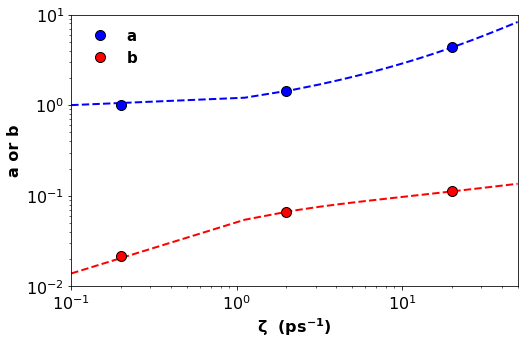

In [22]:
figAX2b, ax2b = plt.subplots(1,1, num=23918, figsize=(8,5))
ax2b.loglog(zeta_array, a_array, color='blue', linestyle='--', linewidth=2)
dfplot2b.plot(x=r'$\zeta$',y='a', ax = ax2b, linestyle='', marker='o', color='blue', markeredgecolor='k', markersize=10)
ax2b.loglog(zeta_array, b_array, color='red', linestyle='--', linewidth=2)
dfplot2b.plot(x=r'$\zeta$',y='b', ax = ax2b, linestyle='', marker='o', color='red', markeredgecolor='k',markersize=10)
ax2b.tick_params(labelsize=16)
ax2b.set_ylabel('a or b', weight='bold', fontsize=16)
ax2b.set_xlabel(r'$\mathbf{\zeta \ \ (ps^{-1})}$', fontsize=16)
ax2b.legend(frameon=False,prop={'size':15, 'weight':'bold'})
ax2b.set_ylim(0.01, 10)
ax2b.set_xlim(0.1,50)

figAX2b.savefig('{}Figure2b_ZetaScalingRelation_updated.png'.format(CorrFuncLoc2), dpi=600, bbox_inches='tight')

In [ ]:
ScalingT1_T2DF_NVE['NVE_t1'].values.astype('float64').shape

In [ ]:
NMRRelax_FitDF_UBQ_NVE.plot(x='Resname', y='C_a')
NMRRelax_FitDF_UBQ_NVT_20ps.plot(x='Resname', y='C_a', ax=plt.gca())

In [ ]:
NMRRelax_FitDF_UBQ_NVE.plot(x='Resname', y='C_b')
NMRRelax_FitDF_UBQ_NVT_20ps.plot(x='Resname', y='C_b', ax=plt.gca())

## Figure 3: Tau_a, tau_b vs. Residue 
### 5 Subplots with  add_axes
#### S1: Amplitudes of fit y_limit = 0,1.0 
#### S2: $\tau_1$ values
#### S3: $\tau_2$ values
#### S4: Secondary Structure small plot
#### S5: SASA values small plot 

In [19]:
def _read_DSSPSum(loc_df, fname, protein, ensemble, coupling=None):
    
    AMBDSSPDICT = {0:'Coil',1:r'Parallel $\beta$-sheet',2:r'Anti-Parallel $\beta$-sheet', 3:'3-10 Helix' ,
                    4:r'$\alpha$-helix', 5:r'$\pi$-helix', 6:'Turn', 7:'Bend', 8:'PPII'}
    AMBDSSP_DICT = {'Para':r'Parallel $\beta$-sheet', 'Anti':r'Anti-Parallel $\beta$-sheet', '3-10':'3-10 Helix',
                'Alpha':r'$\alpha$-helix', 'Pi':r'$\pi$-helix', 'Turn':'Turn', 'Bend':'Bend'}

    sim_mindx = pd.MultiIndex.from_product([loc_df.index.values, list(AMBDSSP_DICT.values())])
    
    indexdf = pd.read_csv('{}/{}'.format(loc_df[protein].iloc[0,0], fname),
                     index_col=0, delim_whitespace=True, usecols=[0])
    
    sim_DSSP_sumDF = pd.DataFrame(index=indexdf.index.values, columns=sim_mindx).fillna(0.0)
    
    for rind in loc_df.index:
    
        if ensemble == 'NVE':
            sumdf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, ensemble)], fname),
                            index_col=0, delim_whitespace=True)
        elif ensemble == 'NVT':
            sumdf = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, coupling)], fname),
                            index_col=0, delim_whitespace=True)
            
        sumdf = sumdf.rename(columns = AMBDSSP_DICT)
        indxcol = [(rind,cc) for cc in sumdf.columns]
        sim_DSSP_sumDF.loc[sumdf.index.values, indxcol] = sumdf.values
        sim_DSSP_sumDF[(rind,'Coil')] = 1-sim_DSSP_sumDF[rind].sum(axis=1)
        
    return sim_DSSP_sumDF

In [20]:
def _plot_Figure3_SStop(fitdf_nve, fitdf_nvt, ssdatadf, sasadf, tcorr_nve, tcorr_nvt, fsize=(10,18), ylim_t1=(1,8)):
    
    fig_f3, axf3 = plt.subplots(4, 1,  figsize=fsize)
    fig_f3.subplots_adjust(hspace=0.05)
    
    ## Plot DSSP/SS first
    
    
    
    ## Plot the Amplitudes to S1
    fitdf_nve[['Resname','C_a','C_a_err']].plot(x='Resname', y='C_a', yerr='C_a_err', c='blue',
                                                                ax=axf3[1], label=r'$\mathbf{A_1-NVE}$',
                                                         linewidth=2, marker='o', linestyle='-')


    fitdf_nvt[['Resname','C_a','C_a_err']].plot(x='Resname', y='C_a', yerr='C_a_err', c='green',
                                                               ax=axf3[1],
                                                               label=r'$\mathbf{A_1 - NVT : \zeta = 2 \ \ ps^{-1}}$',
                                                               linewidth=2, marker='d', linestyle='-')
    
    
    fitdf_nve[['Resname','C_b','C_b_err']].plot(x='Resname', y='C_b', yerr='C_b_err', c='blue',
                                                ax=axf3[1],  label=r'$\mathbf{A_2 - NVE}$',
                                                linewidth=2, marker='o', linestyle='-.')


    fitdf_nvt[['Resname','C_b','C_b_err']].plot(x='Resname', y='C_b', yerr='C_b_err', c='green',
                                                ax=axf3[1],
                                                label=r'$\mathbf{A_2 - NVT : \zeta = 2 \ \ ps^{-1}}$',
                                                linewidth=2, marker='d', linestyle='-.')
    
    axf3[1].set_ylim(0, 1)
    axf3[1].set_ylabel(r'$\mathbf{A_{1} \ \ and \ \ A_{2}}$', fontsize=15, weight='bold')
    axf3[1].legend(loc='best', frameon=False)
    axf3[1].tick_params(labelsize=15)
    
    ## Plot the Tau_1 to S2
    fitdf_nve[['Resname','tau_a','tau_a_err']].plot(x='Resname', y='tau_a', yerr='tau_a_err', c='blue',
                                                    ax=axf3[2], label=r'$\mathbf{NVE}$', logy=True,
                                                    linewidth=2, marker='o')
    
    axf3[2].axhline(tcorr_nve, xmin=0, xmax=sasadf.shape[0], 
                    linewidth=2, linestyle='--', color='blue')
    
    fitdf_nvt[['Resname','tau_a','tau_a_err']].plot(x='Resname', y='tau_a', yerr='tau_a_err', c='green',
                                                    ax=axf3[2], logy=True,
                                                    label=r'$\mathbf{ NVT : \zeta = 2 \ \ ps^{-1}}$', 
                                                    linewidth=2, marker='d')
    
    axf3[2].axhline(tcorr_nvt, xmin=0, xmax=sasadf.shape[0],
                    linewidth=2, linestyle='--', color='green')
    
    if (ylim_t1[1]-ylim_t1[0]) > 10:
        axf3[2].tick_params(labelsize=15, which='major')
    else: 
        axf3[2].tick_params(labelsize=15, which='both')
        axf3[2].set_yticks(np.linspace(np.ceil(ylim_t1[0]).astype(int), ylim_t1[1],
                                       ylim_t1[1] - np.ceil(ylim_t1[0]).astype(int) + 1)[1:-1], minor=True)
        axf3[2].set_yticklabels(np.linspace(np.ceil(ylim_t1[0]).astype(int), ylim_t1[1],
                                            ylim_t1[1] - np.ceil(ylim_t1[0]).astype(int) + 1)[1:-1], minor=True)
        axf3[2].yaxis.set_minor_formatter(mticker.ScalarFormatter())
        
    axf3[2].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    axf3[2].set_ylim(ylim_t1[0], ylim_t1[1])
    axf3[2].set_ylabel(r'$\mathbf{\tau_{1} \ \ (ns)}$', fontsize=15, weight='bold')
    axf3[2].legend(loc='best', frameon=False)
    
    ## Plot Tau_2 to S3 
    fitdf_nve[['Resname','tau_b','tau_b_err']].plot(x='Resname', y='tau_b', yerr='tau_b_err', c='blue',
                                                    ax=axf3[3], logy=True, label=r'$\mathbf{NVE}$',
                                                    linewidth=2, marker='o')
    
    fitdf_nvt[['Resname','tau_b','tau_b_err']].plot(x='Resname', y='tau_b', yerr='tau_b_err', c='green',
                                                    ax=axf3[3], logy=True,
                                                    label=r'$\mathbf{ NVT : \zeta = 2 \ \ ps^{-1}}$', 
                                                    linewidth=2, marker='d')
    
    axf3[3].set_xlabel('Residue', fontsize=15, weight='bold')
    axf3[3].set_ylabel(r'$\mathbf{\tau_{2} \ \ (ns)}$', fontsize=15, weight='bold')
    axf3[3].set_ylim(3e-4, 1e0)
    axf3[3].legend(loc='best', frameon=False)
    
    for axfit in axf3:
        axfit.set_xlim(0, ssdatadf.shape[0]+1)
        axfit.set_xticks(np.arange(0, ssdatadf.shape[0], 10))
        axfit.set_xticks(np.arange(0, ssdatadf.shape[0], 5), minor=True)
        axfit.tick_params(labelsize=15)
        
    axf3[1].set_xticklabels([])
    axf3[2].set_xticklabels([])
    axf3[3].set_xticklabels(np.arange(0, ssdatadf.shape[0],10))
    
    fig_f3.canvas.draw()
    ## Align Ylabels
    f3s1_ylbl_pos = axf3[1].yaxis.label.get_position()
    f3s2_ylbl_pos = axf3[2].yaxis.label.get_position()
    f3s3_ylbl_pos = axf3[3].yaxis.label.get_position()
    print(f3s1_ylbl_pos, f3s2_ylbl_pos, f3s3_ylbl_pos)
    axf3[2].set_ylabel(r'$\mathbf{\tau_{1} \ \ (ns)}$', labelpad = (f3s2_ylbl_pos[0] - f3s3_ylbl_pos[0] + 4.0),
                       fontsize=15, weight='bold')
    axf3[1].set_ylabel(r'$\mathbf{A_{1} \ \ or \ \ A_{2}}$', labelpad = (f3s1_ylbl_pos[0] - f3s3_ylbl_pos[0] + 4.0),
                       fontsize=15, weight='bold')
    
    
    s3_bounds = axf3[0].get_position().bounds
    axf3[0].axis('off')
    print(s3_bounds)
    axSS = fig_f3.add_axes([0.125, s3_bounds[1]  + 0.0515, s3_bounds[2], .05])
    axSS.set_ylim(0.0, 1.0)
    ssdatadf[['Helix', r'$\beta$-Strand', 'Turn']].plot.bar(ax=axSS, color=SatCMap_SS_F3,
                                                                 linewidth=1, stacked=True, edgecolor='k', legend=False)
    axSS.tick_params(labelsize=15)
    axSS.set_yticks([])
    axSS.set_yticklabels([])
    axSS.set_xticks(np.arange(-1, ssdatadf.shape[0], 10))
    axSS.set_xticks(np.arange(-1, ssdatadf.shape[0], 5), minor=True)
    axSS.set_ylabel('SS', fontsize=15, weight='bold')
    axSS.set_xticklabels([])
    axSS.set_xlim(-1, ssdatadf.shape[0])
              
                  
    axSASA = fig_f3.add_axes([0.125, s3_bounds[1], s3_bounds[2], .05])
    
    cmap = axSASA.imshow(sasadf['Stat'].values[np.newaxis,:], cmap='gist_yarg', aspect='auto', vmin=-0.75, vmax=1.0)
    axSASA.set_yticks([])
    axSASA.set_xticks(np.arange(-1, sasadf.shape[0], 10))
    axSASA.set_xticks(np.arange(-1, sasadf.shape[0], 5), minor=True)
    axSASA.set_xticklabels([])
    axSASA.set_ylabel('SASA', fontsize=15, weight='bold')
    axSASA.set_xlim(-1, ssdatadf.shape[0])
    
    return fig_f3

In [21]:
def _plot_Figure3(fitdf_nve, fitdf_nvt, ssdatadf, sasadf, tcorr_nve, tcorr_nvt, fsize=(10,18), ylim_t1=(1,8)):
    
    fig_f3, axf3 = plt.subplots(4, 1,  figsize=fsize)
    fig_f3.subplots_adjust(hspace=0.05)
    
    ## Plot DSSP/SS first
    
    
    ## Plot the Amplitudes to S1
    fitdf_nve[['Resname','C_a','C_a_err']].plot(x='Resname', y='C_a', yerr='C_a_err', c='blue',
                                                                ax=axf3[0], label=r'$\mathbf{A_1-NVE}$',
                                                         linewidth=2, marker='o', linestyle='-')


    fitdf_nvt[['Resname','C_a','C_a_err']].plot(x='Resname', y='C_a', yerr='C_a_err', c='green',
                                                               ax=axf3[0],
                                                               label=r'$\mathbf{A_1 - NVT : \zeta = 2 \ \ ps^{-1}}$',
                                                               linewidth=2, marker='d', linestyle='-')
    
    
    fitdf_nve[['Resname','C_b','C_b_err']].plot(x='Resname', y='C_b', yerr='C_b_err', c='blue',
                                                ax=axf3[0],  label=r'$\mathbf{A_2 - NVE}$',
                                                linewidth=2, marker='o', linestyle='-.')


    fitdf_nvt[['Resname','C_b','C_b_err']].plot(x='Resname', y='C_b', yerr='C_b_err', c='green',
                                                ax=axf3[0],
                                                label=r'$\mathbf{A_2 - NVT : \zeta = 2 \ \ ps^{-1}}$',
                                                linewidth=2, marker='d', linestyle='-.')
    
    axf3[0].set_ylim(0, 1)
    axf3[0].set_ylabel(r'$\mathbf{A_{1} \ \ and \ \ A_{2}}$', fontsize=15, weight='bold')
    axf3[0].legend(loc='best', frameon=False)
    axf3[0].tick_params(labelsize=15)
    
    ## Plot the Tau_1 to S2
    fitdf_nve[['Resname','tau_a','tau_a_err']].plot(x='Resname', y='tau_a', yerr='tau_a_err', c='blue',
                                                    ax=axf3[1], label=r'$\mathbf{NVE}$',
                                                    linewidth=2, marker='o')
    axf3[1].axhline(tcorr_nve, xmin=0, xmax=sasadf.shape[0], 
                    linewidth=2, linestyle='--', color='blue')
    
    fitdf_nvt[['Resname', 'tau_a', 'tau_a_err']].plot(x='Resname', y='tau_a', yerr='tau_a_err', c='green',
                                                    ax=axf3[1],logy=True,
                                                    label=r'$\mathbf{ NVT : \zeta = 2 \ \ ps^{-1}}$', 
                                                    linewidth=2, marker='d')
    
    axf3[1].axhline(tcorr_nvt, xmin=0, xmax=sasadf.shape[0],
                    linewidth=2, linestyle='--', color='green')
    
    if (ylim_t1[1]-ylim_t1[0]) > 10:
        axf3[1].tick_params(labelsize=15, which='major')
    else: 
        axf3[1].tick_params(labelsize=15, which='both')
        axf3[1].set_yticks(np.linspace(np.ceil(ylim_t1[0]).astype(int), ylim_t1[1],
                                        ylim_t1[1] - np.ceil(ylim_t1[0]).astype(int) + 1)[1:-1], minor=True)
        axf3[1].set_yticklabels(np.linspace(np.ceil(ylim_t1[0]).astype(int), ylim_t1[1],
                                            ylim_t1[1] - np.ceil(ylim_t1[0]).astype(int) + 1)[1:-1], minor=True)
        axf3[1].yaxis.set_minor_formatter(mticker.ScalarFormatter())
        
    axf3[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    
    axf3[1].set_ylim(ylim_t1[0], ylim_t1[1])
    axf3[1].set_ylabel(r'$\mathbf{\tau_{1} \ \ (ns)}$', fontsize=15, weight='bold')
    axf3[1].legend(loc='best', frameon=False)
    
    ## Plot Tau_2 to S3 
    fitdf_nve[['Resname','tau_b','tau_b_err']].plot(x='Resname', y='tau_b', yerr='tau_b_err', c='blue',
                                                    ax=axf3[2], logy=True, label=r'$\mathbf{NVE}$',
                                                    linewidth=2, marker='o')
    
    fitdf_nvt[['Resname','tau_b','tau_b_err']].plot(x='Resname', y='tau_b', yerr='tau_b_err', c='green',
                                                    ax=axf3[2], logy=True,
                                                    label=r'$\mathbf{ NVT : \zeta = 2 \ \ ps^{-1}}$', 
                                                    linewidth=2, marker='d')
    
    axf3[2].set_xlabel('Residue', fontsize=15, weight='bold')
    axf3[2].set_ylabel(r'$\mathbf{\tau_{2} \ \ (ns)}$', fontsize=15, weight='bold')
    axf3[2].set_ylim(3e-4, 1e0)
    axf3[2].legend(loc='best', frameon=False)
    
    for axfit in axf3:
        axfit.set_xlim(0, ssdatadf.shape[0]+1)
        axfit.set_xticks(np.arange(0, ssdatadf.shape[0], 10))
        axfit.set_xticks(np.arange(0, ssdatadf.shape[0], 5), minor=True)
        axfit.tick_params(labelsize=15)
        
    axf3[0].set_xticklabels([])
    axf3[1].set_xticklabels([])
    axf3[2].set_xticklabels(np.arange(0, ssdatadf.shape[0],10))
    
    fig_f3.canvas.draw()
    ## Align Ylabels
    f3s1_ylbl_pos = axf3[0].yaxis.label.get_position()
    f3s2_ylbl_pos = axf3[1].yaxis.label.get_position()
    f3s3_ylbl_pos = axf3[2].yaxis.label.get_position()
    print(f3s1_ylbl_pos, f3s2_ylbl_pos, f3s3_ylbl_pos)
    axf3[1].set_ylabel(r'$\mathbf{\tau_{1} \ \ (ns)}$', labelpad = (f3s2_ylbl_pos[0] - f3s3_ylbl_pos[0] + 4.0),
                       fontsize=15, weight='bold')
    axf3[0].set_ylabel(r'$\mathbf{A_{1} \ \ or \ \ A_{2}}$', labelpad = (f3s1_ylbl_pos[0] - f3s3_ylbl_pos[0] + 4.0),
                       fontsize=15, weight='bold')
    
    axf3[3].axis('off')
    s3_bounds = axf3[2].get_position().bounds
    
    axSS = fig_f3.add_axes([0.125, s3_bounds[1] - 0.05 - 0.035, s3_bounds[2], .05])
    axSS.set_ylim(0.0, 1.0)
    ssdatadf[['Helix', r'$\beta$-Strand', 'Turn']].plot.bar(ax=axSS, color=SatCMap_SS_F3,
                                                                 linewidth=1, stacked=True, edgecolor='k', legend=False)
    axSS.tick_params(labelsize=15)
    axSS.set_yticks([])
    axSS.set_yticklabels([])
    axSS.set_xticks(np.arange(-1,ssdatadf.shape[0],10))
    axSS.set_xticks(np.arange(-1,ssdatadf.shape[0],5), minor=True)
    axSS.set_ylabel('SS', fontsize=15, weight='bold')
    axSS.set_xticklabels([])
    axSS.set_xlim(-1,ssdatadf.shape[0])
              
                  
    axSASA = fig_f3.add_axes([0.125, s3_bounds[1] - 0.05  - 0.086, s3_bounds[2], .05])
    
    cmap = axSASA.imshow(sasadf['Stat'].values[np.newaxis,:], cmap='gist_yarg', aspect='auto', vmin=-0.75, vmax=1.0)
    axSASA.set_yticks([])
    axSASA.set_xticks(np.arange(-1, sasadf.shape[0], 10))
    axSASA.set_xticks(np.arange(-1, sasadf.shape[0], 5), minor=True)
    axSASA.set_xticklabels([])
    axSASA.set_ylabel('SASA', fontsize=15, weight='bold')
    axSASA.set_xlim(-1, ssdatadf.shape[0])
    
    return fig_f3

In [22]:
def _plot_Figure3_noSASA(fitdf_nve, fitdf_nvt, tcorr_nve, tcorr_nvt, nres, cf=2,  fsize=(10,18), ylim_t1=(1,8)):
    
    fig_f3, axf3 = plt.subplots(3, 1,  figsize=fsize, sharex=True)
    fig_f3.subplots_adjust(hspace=0.05)
    
    ## Plot the Amplitudes to S1
    fitdf_nve[['Resname','C_a','C_a_err']].plot(x='Resname', y='C_a', yerr='C_a_err', c='blue',
                                                                ax=axf3[0], label=r'$\mathbf{A_1-NVE}$',
                                                         linewidth=2, marker='o', linestyle='-')


    fitdf_nvt[['Resname','C_a','C_a_err']].plot(x='Resname', y='C_a', yerr='C_a_err', c='green',
                                                               ax=axf3[0],
                                                               label=r'$\mathbf{{A_1 - NVT : \zeta = {} \ \ ps^{{-1}}}}$'.format(cf),
                                                               linewidth=2, marker='d', linestyle='-')
    
    
    fitdf_nve[['Resname','C_b','C_b_err']].plot(x='Resname', y='C_b', yerr='C_b_err', c='blue',
                                                ax=axf3[0],  label=r'$\mathbf{A_2 - NVE}$',
                                                linewidth=2, marker='o', linestyle='-.')


    fitdf_nvt[['Resname','C_b','C_b_err']].plot(x='Resname', y='C_b', yerr='C_b_err', c='green',
                                                ax=axf3[0],
                                                label=r'$\mathbf{{A_2 - NVT : \zeta = {} \ \ ps^{{-1}}}}$'.format(cf),
                                                linewidth=2, marker='d', linestyle='-.')
    
    axf3[0].set_ylim(0, 1)
    axf3[0].set_ylabel(r'$\mathbf{A_{1} \ \ and \ \ A_{2}}$', fontsize=15, weight='bold')
    axf3[0].legend(loc='best', frameon=False)
    axf3[0].tick_params(labelsize=15)
    
    ## Plot the Tau_1 to S2
    fitdf_nve[['Resname','tau_a','tau_a_err']].plot(x='Resname', y='tau_a', yerr='tau_a_err', c='blue',
                                                    ax=axf3[1], label=r'$\mathbf{NVE}$',
                                                    linewidth=2, marker='o')
    
    axf3[1].axhline(tcorr_nve, xmin=0, xmax=fitdf_nve.shape[0], 
                    linewidth=2, linestyle='--', color='blue')
    
    fitdf_nvt[['Resname','tau_a','tau_a_err']].plot(x='Resname', y='tau_a', yerr='tau_a_err', c='green',
                                                    ax=axf3[1], logy=True,
                                                    label=r'$\mathbf{{ NVT : \zeta = {} \ \ ps^{{-1}}}}$'.format(cf), 
                                                    linewidth=2, marker='d')
    
    axf3[1].axhline(tcorr_nvt, xmin=0, xmax=fitdf_nve.shape[0],
                    linewidth=2, linestyle='--', color='green')
    
    if (ylim_t1[1]-ylim_t1[0]) > 10:
        axf3[1].tick_params(labelsize=15, which='major')
    else: 
        axf3[1].tick_params(labelsize=15, which='both')
        axf3[1].set_yticks(np.linspace(np.ceil(ylim_t1[0]).astype(int), ylim_t1[1],
                                      ylim_t1[1] - np.ceil(ylim_t1[0]).astype(int) + 1)[1:-1], minor=True)
        axf3[1].set_yticklabels(np.linspace(np.ceil(ylim_t1[0]).astype(int), ylim_t1[1],
                                            ylim_t1[1] - np.ceil(ylim_t1[0]).astype(int) + 1)[1:-1], minor=True)
        axf3[1].yaxis.set_minor_formatter(mticker.ScalarFormatter())
    
    #axf3[1].set_yticklabels(np.linspace(ylim_t1[0], ylim_t1[1], ylim_t1[1] - ylim_t1[0]+1)[1:-1], major=True)
    axf3[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    
    axf3[1].set_ylim(ylim_t1[0], ylim_t1[1])
    axf3[1].set_ylabel(r'$\mathbf{\tau_{1} \ \ (ns)}$', fontsize=15, weight='bold')
    axf3[1].legend(loc='best', frameon=False)
    
    ## Plot Tau_2 to S3 
    fitdf_nve[['Resname','tau_b','tau_b_err']].plot(x='Resname', y='tau_b', yerr='tau_b_err', c='blue',
                                                    ax=axf3[2], logy=True, 
                                                    label=r'$\mathbf{NVE}$',
                                                    linewidth=2, marker='o')
    
    fitdf_nvt[['Resname','tau_b','tau_b_err']].plot(x='Resname', y='tau_b', yerr='tau_b_err', c='green',
                                                    ax=axf3[2], logy=True,
                                                    label=r'$\mathbf{{ NVT : \zeta = {} \ \ ps^{{-1}}}}$'.format(cf), 
                                                    linewidth=2, marker='d')
    
    axf3[2].set_xlabel('Residue', fontsize=15, weight='bold')
    axf3[2].set_ylabel(r'$\mathbf{\tau_{2} \ \ (ns)}$', fontsize=15, weight='bold')
    axf3[2].set_ylim(3e-4, 1e0)
    axf3[2].set_xlim(-2, nres+1)
    axf3[2].legend(loc='best', frameon=False)
    
    for axfit in axf3:
        axfit.set_xlim(0, nres+1)
        axfit.set_xticks(np.arange(0, nres+1, 10))
        axfit.set_xticks(np.arange(0, nres+1, 5), minor=True)
        axfit.tick_params(labelsize=15)
        
    axf3[0].set_xticklabels([])
    axf3[1].set_xticklabels([])
    axf3[2].set_xticklabels(np.arange(0,nres+1,10))
    axf3[2].set_xlim(-1, nres+1)
    
    fig_f3.canvas.draw()
    ## Align Ylabels
    f3s1_ylbl_pos = axf3[0].yaxis.label.get_position()
    f3s2_ylbl_pos = axf3[1].yaxis.label.get_position()
    f3s3_ylbl_pos = axf3[2].yaxis.label.get_position()
    print(f3s1_ylbl_pos, f3s2_ylbl_pos, f3s3_ylbl_pos)
    axf3[1].set_ylabel(r'$\mathbf{\tau_{1} \ \ (ns)}$', labelpad = (f3s2_ylbl_pos[0] - f3s3_ylbl_pos[0] + 4.0),
                       fontsize=15, weight='bold')
    axf3[0].set_ylabel(r'$\mathbf{A_{1} \ \ or \ \ A_{2}}$', labelpad = (f3s1_ylbl_pos[0] - f3s3_ylbl_pos[0] + 4.0),
                       fontsize=15, weight='bold')

    
    return fig_f3

In [23]:
def _read_SASASim(ens_loc, protein, atom_df, coupling=''):
    
    reference_SASA_dict = {'ALA':106,'ARG':248,'ASN':157,'ASP':163,
                      'CYS':135,'GLN':198,'GLU':194,'GLY':84,
                      'HIS':184,'ILE':169,'LEU':164,'LYS':205,
                      'MET':188,'PHE':197,'PRO':136,'SER':130,
                      'THR':142,'TRP':227, 'TYR':222,'VAL':142}
    
    if len(coupling) > 0:
        sasa_sim = (pd.read_csv('{}{}/{}/{}/AvgSASA_Res.csv'.format(CorrFuncLoc2, protein, ens_loc, coupling))
                    .rename(columns={'0':'SASA'}))
    else:
        sasa_sim = (pd.read_csv('{}{}/{}/AvgSASA_Res.csv'.format(CorrFuncLoc2, protein, ens_loc))
                    .rename(columns={'0':'SASA'}))
        
    sasa_sim['RefSASA'] = atom_df['RESNAME'].apply(lambda rr: rr[:3]).replace(reference_SASA_dict)
    sasa_sim['Stat'] = sasa_sim[['RefSASA','SASA']].apply(lambda row: 1-row.SASA/row.RefSASA, axis=1)

    return sasa_sim

In [24]:
def _assign_DSSP(dssp_df):
    
    combinedict = {r'Parallel $\beta$-sheet':r'$\beta$-Strand', r'Anti-Parallel $\beta$-sheet':r'$\beta$-Strand',
                   r'$\alpha$-helix':'Helix','3-10 Helix':r'Helix', r'$\pi$-helix':r'Helix',
                   'Bend':'Turn'}
    
    dssp_df_re = dssp_df.rename(columns=combinedict,level=1).sort_index(axis=1)
    new_mindx = pd.MultiIndex.from_product([dssp_df_re.columns.levels[0], np.unique(dssp_df_re.columns.levels[-1])])
    dssp_df_simp = pd.DataFrame(index=dssp_df_re.index, columns=new_mindx).fillna(0.0)

    for col in dssp_df_re.columns.levels[0]:
        dssp_combined_sum = dssp_df_re[col].groupby(axis=1,level=0).sum()
        col_list = [(col,dssp_name) for dssp_name in dssp_combined_sum.columns]
        dssp_df_simp[col_list] = dssp_combined_sum
        
    dssp_df_simp = dssp_df_simp.mean(axis=1,level=1)
    dssp_assign = dssp_df_simp.apply(lambda row: row.index[np.where(row==row.max())[0][0]],axis=1)
    
    return dssp_assign, dssp_df_simp

In [29]:
GB3_SASA_SIM = _read_SASASim('PROD_NVT', 'GB3',GB3atom_df, coupling='CF2ps')
UBQ_SASA_SIM = _read_SASASim('PROD_NVT', 'Ubiquitin', UBQatom_df, coupling='CF2ps')

In [30]:
gb3_NVT_DSSP = _read_DSSPSum(LocDF_NVT,  'GB3_SS_Sum.out', 'GB3', 'NVT', coupling='CF2ps')
gb3_assign_dssp, gb3_simplified_dssp = _assign_DSSP(gb3_NVT_DSSP)
ubq_NVT_DSSP = _read_DSSPSum(LocDF_NVT,  'UBQ_SS_Sum.out', 'Ubiquitin', 'NVT', coupling='CF2ps')
ubq_assign_dssp, ubq_simplified_dssp = _assign_DSSP(ubq_NVT_DSSP)

In [31]:
gb3_assign_dssp.to_csv('{}{}/GB3_AssignDSSP.csv'.format(CorrFuncLoc2,'GB3'))
ubq_assign_dssp.to_csv('{}{}/UBQ_AssignDSSP.csv'.format(CorrFuncLoc2,'Ubiquitin'))

In [ ]:
fig_s3_gb3 = _plot_Figure3(NMRRelax_FitDF_GB3_NVE, NMRRelax_FitDF_GB3_NVT_2ps, gb3_simplified_dssp, GB3_SASA_SIM, 3.22, 6.09, fsize=(10,18), ylim_t1=(2,8))
fig_s3_gb3.savefig('{}{}/Analysis/Figure3_GB3_Template_NewFits.png'.format(CorrFuncLoc2,'GB3'), dpi=600, bbox_inches='tight')

In [ ]:
fig_s3_gb3ss = _plot_Figure3_SStop(NMRRelax_FitDF_GB3_NVE, NMRRelax_FitDF_GB3_NVT_2ps, gb3_simplified_dssp, GB3_SASA_SIM, 3.22, 6.09, fsize=(10,18), ylim_t1=(2,8))
fig_s3_gb3ss.savefig('{}{}/Analysis/Figure3_GB3_Template_NewFits_SSTop.png'.format(CorrFuncLoc2,'GB3'), dpi=600, bbox_inches='tight')

In [ ]:
fig_s3_gb3_02 = _plot_Figure3_noSASA(NMRRelax_FitDF_GB3_NVE, NMRRelax_FitDF_GB3_NVT_02ps, 3.22, 3.51, 56, cf=0.2, fsize=(10,18), ylim_t1=(2,8))
fig_s3_gb3_02.savefig('{}{}/Analysis/FigureS5_GB3_Template_CF02ps_NewFits.png'.format(CorrFuncLoc2,'GB3'), dpi=600, bbox_inches='tight')

In [ ]:
fig_s3_gb3_20 = _plot_Figure3_noSASA(NMRRelax_FitDF_GB3_NVE, NMRRelax_FitDF_GB3_NVT_20ps, 3.22, 26.03, 56, cf=20,  fsize=(10,18), ylim_t1=(1,40))
fig_s3_gb3_20.savefig('{}{}/Analysis/Figure3_GB3_Template_CF20ps_NewFits.png'.format(CorrFuncLoc2,'GB3'), dpi=600, bbox_inches='tight')

In [ ]:
fig_s3_ubq = _plot_Figure3(NMRRelax_FitDF_UBQ_NVE, NMRRelax_FitDF_UBQ_NVT_2ps, ubq_simplified_dssp, UBQ_SASA_SIM, 4.33, 8.77, fsize=(10,18), ylim_t1=(0.5, 12))
fig_s3_ubq.savefig('{}{}/Analysis/Figure3_Ubiquitin_Template_NewFits.png'.format(CorrFuncLoc2,'Ubiquitin'), dpi=600, bbox_inches='tight')

In [ ]:
fig_s3_ubqss = _plot_Figure3_SStop(NMRRelax_FitDF_UBQ_NVE, NMRRelax_FitDF_UBQ_NVT_2ps, ubq_simplified_dssp, UBQ_SASA_SIM, 4.33, 8.77, fsize=(12,18), ylim_t1=(0.5, 12))
fig_s3_ubqss.savefig('{}{}/Analysis/Figure3_Ubiquitin_Template_NewFits_SStop.png'.format(CorrFuncLoc2,'Ubiquitin'), dpi=600, bbox_inches='tight')

In [ ]:
fig_s3_ubq_02 = _plot_Figure3_noSASA(NMRRelax_FitDF_UBQ_NVE, NMRRelax_FitDF_UBQ_NVT_02ps, 4.33, 4.92, 76, cf=0.2, fsize=(12,18), ylim_t1=(0.5, 8))
fig_s3_ubq_02.savefig('{}{}/Analysis/FigureS5_Ubiquitin_Template_CF02ps_NewFits.png'.format(CorrFuncLoc2,'Ubiquitin'), dpi=600, bbox_inches='tight')

In [ ]:
np.ceil(0.5).astype(int)

In [ ]:
fig_s3_ubq_20 = _plot_Figure3_noSASA(NMRRelax_FitDF_UBQ_NVE, NMRRelax_FitDF_UBQ_NVT_20ps, 4.33, 39.83,76, cf=20, fsize=(12,18), ylim_t1=(0.5, 55))
fig_s3_ubq_20.savefig('{}{}/Analysis/FigureS5_Ubiquitin_Template_CF20ps_NewFits.png'.format(CorrFuncLoc2,'Ubiquitin'), dpi=600, bbox_inches='tight')

### Figure 3 Test Code

In [ ]:
combinedict = {r'Parallel $\beta$-sheet':r'$\beta$-Strand', r'Anti-Parallel $\beta$-sheet':r'$\beta$-Strand',
                   r'$\alpha$-helix':'Helix','3-10 Helix':r'Helix', r'$\pi$-helix':r'Helix',
                   'Bend':'Turn'}

gb3_NVT_DSSP_re = gb3_NVT_DSSP.rename(columns=combinedict,level=1).sort_index(axis=1)
new_mindx = pd.MultiIndex.from_product([gb3_NVT_DSSP_re.columns.levels[0], np.unique(gb3_NVT_DSSP_re.columns.levels[-1])])
gb3_NVT_Simplified = pd.DataFrame(index=gb3_NVT_DSSP_re.index, columns=new_mindx).fillna(0.0)

for col in gb3_NVT_DSSP_re.columns.levels[0]:
    dssp_combined_sum = gb3_NVT_DSSP_re[col].groupby(axis=1,level=0).sum()
    col_list = [(col,dssp_name) for dssp_name in dssp_combined_sum.columns]
    gb3_NVT_Simplified[col_list] = dssp_combined_sum
    

In [ ]:
gb3_NVT_Simplified.mean(axis=1,level=1).plot.bar(cmap='Spectral',stacked=True)

In [ ]:
fig_s3_gb3.axes[2].yaxis.label.get_position(), fig_s3_gb3.axes[1].yaxis.label.get_position()

In [ ]:
f3s3_ylbl_pos = fig_s3_gb3.axes[2].yaxis.label.get_position()

In [ ]:
f3s2_ylbl_pos = fig_s3_gb3.axes[1].yaxis.label.get_position()

In [ ]:
f3s1_ylbl_pos = fig_s3_gb3.axes[0].yaxis.label.get_position()

In [ ]:
fig_s3_gb3.axes[0].yaxis.set_label(labelpad)

In [ ]:
f3s2_ylbl_pos[0] - f3s3_ylbl_pos[0] + 4.0

In [ ]:
f3s1_ylbl_pos[0] - f3s3_ylbl_pos[0] + 4.0

In [ ]:
fig_f3, axf3 = plt.subplots(4, 1, sharex=True,  figsize=(10,18))
fig_f3.subplots_adjust(hspace = 0.05)
pos_ax3 = axf3[2].get_position().bounds
axf3[3].axis('off')
print(pos_ax3)
## get_position returns [[x0, y0], [x[1],y[1]]]
## add_axes[x[0], y[0]-width, x[1]-x[0], width] 

axSS = fig_f3.add_axes([0.125, pos_ax3[1] - 0.05 - 0.035, pos_ax3[2], .05])
axSASA = fig_f3.add_axes([0.125, pos_ax3[1] - 0.05  - 0.135, pos_ax3[2], .05])

In [ ]:
pos_ax3.bounds

## Figure 4: Violin Plot of tau_a & tau_b vs. Coupling Frequency

In [25]:
def _conv_4Violin(nmrdf_list, dsspassign_list):
    """
    inputs: nmrdf_list: fits in order [nve, 0.2 ps^-1, 2 ps^-1, 20 ps^-1 ] 
            dsspassign_list: dssp assignments in the same order as above
    """
    Sims_TauA_NVE = nmrdf_list[0][['Resname','tau_a']].copy()
    Sims_TauA_NVE['Ensemble'] = 'NVE'
    Sims_TauA_NVE['Coupling'] = 0.0

    Sims_TauA_NVT_02ps = nmrdf_list[1][['Resname','tau_a']].copy()
    Sims_TauA_NVT_02ps['Ensemble'] = 'NVT'
    Sims_TauA_NVT_02ps['Coupling'] = 0.2

    Sims_TauA_NVT_2ps = nmrdf_list[2][['Resname','tau_a']].copy()
    Sims_TauA_NVT_2ps['Ensemble'] = 'NVT'
    Sims_TauA_NVT_2ps['Coupling'] = 2.0

    Sims_TauA_NVT_20ps = nmrdf_list[3][['Resname','tau_a']].copy()
    Sims_TauA_NVT_20ps['Ensemble'] = 'NVT'
    Sims_TauA_NVT_20ps['Coupling'] = 20.0
        
    Sims_TauA = pd.concat([Sims_TauA_NVE, 
                            Sims_TauA_NVT_02ps, 
                            Sims_TauA_NVT_2ps, 
                            Sims_TauA_NVT_20ps])
    
    Sims_TauA['log(tau_a)'] = Sims_TauA['tau_a'].apply(np.log10)

    ## Make tau_b values
    Sims_TauB_NVE = nmrdf_list[0][['Resname','tau_b']].copy()
    Sims_TauB_NVE['Ensemble'] = 'NVE'
    Sims_TauB_NVE['Coupling'] = 0.0
    Sims_TauB_NVE = (Sims_TauB_NVE.merge(dsspassign_list[0].reset_index()
                                         .rename(columns={'index':'Resname',0:'SS'}), how='left'))
    
    Sims_TauB_NVT_02ps = nmrdf_list[1][['Resname','tau_b']].copy()
    Sims_TauB_NVT_02ps['Ensemble'] = 'NVT'
    Sims_TauB_NVT_02ps['Coupling'] = 0.2
    Sims_TauB_NVT_02ps = (Sims_TauB_NVT_02ps.merge(dsspassign_list[0].reset_index()
                                         .rename(columns={'index':'Resname',0:'SS'}), how='left'))
    
    Sims_TauB_NVT_2ps = nmrdf_list[2][['Resname','tau_b']].copy()
    Sims_TauB_NVT_2ps['Ensemble'] = 'NVT'
    Sims_TauB_NVT_2ps['Coupling'] = 2.0
    Sims_TauB_NVT_2ps = (Sims_TauB_NVT_2ps.merge(dsspassign_list[0].reset_index()
                                         .rename(columns={'index':'Resname',0:'SS'}), how='left'))
    
    Sims_TauB_NVT_20ps = nmrdf_list[3][['Resname','tau_b']].copy()
    Sims_TauB_NVT_20ps['Ensemble'] = 'NVT'
    Sims_TauB_NVT_20ps['Coupling'] = 20.0
    Sims_TauB_NVT_20ps = (Sims_TauB_NVT_20ps.merge(dsspassign_list[0].reset_index()
                                         .rename(columns={'index':'Resname',0:'SS'}), how='left'))
        
    Sims_TauB = pd.concat([Sims_TauB_NVE, 
                            Sims_TauB_NVT_02ps, 
                            Sims_TauB_NVT_2ps, 
                            Sims_TauB_NVT_20ps])
    
    Sims_TauB['log(tau_b)'] = Sims_TauB['tau_b'].apply(np.log10)
    
    return Sims_TauA, Sims_TauB

In [26]:
def _plot_ViolinPlot(compare_coupfreq_sims_ta, compare_coupfreq_sims_tb, ylim_t1=(1,50)):
    
    couplingvsTb_Mean = compare_coupfreq_sims_tb[['tau_b', 'log(tau_b)', 'Coupling']].groupby('Coupling').mean().reset_index()
    #couplingvsTb_Mean['log(tau_b)'] = couplingvsTb_Mean['tau_b'].apply(np.log10)
    couplingvsTa_Mean = compare_coupfreq_sims_ta[['tau_a', 'log(tau_a)', 'Coupling']].groupby('Coupling').mean().reset_index()
    #couplingvsTa_Mean['log(tau_a)'] = couplingvsTa_Mean['tau_a'].apply(np.log10)

    figcorvf, axcorvf = plt.subplots(2, 1, figsize=(8, 14), sharex=True)
    figcorvf.subplots_adjust(hspace=0.05)
    
    ##Plot the Violing Plot for Tau_a
    sns.violinplot(x='Coupling', y='log(tau_a)', data=compare_coupfreq_sims_ta.dropna(),ax=axcorvf[0],
                   palette='Pastel2_r', alpha=0.75, cut=1.0, inner='quartile')
    ## Plot the averages
    axcorvf[0].plot(couplingvsTa_Mean['log(tau_a)'].values, color='k', marker='d',
                    linestyle='--', linewidth=2, markersize=8)
    
    ## Format the Axes
    axcorvf[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
    axcorvf[0].yaxis.set_ticks([0.0, 1.0])
    axcorvf[0].yaxis.set_ticks([np.log10(x) for p in range(0, 2) for x in np.linspace(10**p, 10**(p+1), 10)], minor=True)
    axcorvf[0].set_ylim(np.log10(ylim_t1[0]), np.log10(ylim_t1[1]))
    axcorvf[0].tick_params(labelsize=15)
    axcorvf[0].set_xlabel(None)
    axcorvf[0].set_ylabel(r'$\mathbf{\tau_{1} \ \ (ns)}$', fontsize=17)

    ## Plot the Violin Plot for Tau_b
    sns.violinplot(x='Coupling', y='log(tau_b)', data=compare_coupfreq_sims_tb.dropna() ,ax=axcorvf[1],
               palette='Pastel2_r', alpha=0.75, cut=2.5, inner='quartile')
    ## Plot the Swarmplot/Scater for Tau_b
    sns.swarmplot(x='Coupling', y='log(tau_b)', data=compare_coupfreq_sims_tb.dropna(), ax=axcorvf[1],
                  edgecolor='black', linewidth=1.0,
                  hue='SS', hue_order=['Coil', 'Turn', r'$\beta$-Strand','Helix'], palette=SatYelSS_ColorPalette, s=8)
    
    ## Add the edgecolor to the scatter plot handles from the swarmplot
    ss_hndl, ss_lbls = axcorvf[1].get_legend_handles_labels()
    for hndl in ss_hndl:
        hndl.set_edgecolor('k')
    axcorvf[1].legend(ss_hndl, ss_lbls, loc=2, frameon=True,
                      edgecolor='w', facecolor='w', framealpha=0.775, prop={'size':14.5, 'weight':'bold'})

    ## Plot the Means for Tau_b
    axcorvf[1].plot(couplingvsTb_Mean['log(tau_b)'].values, color='k', marker='d', linestyle='--', linewidth=2, markersize=8)
    
    ## Format the Axes
    
    axcorvf[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
    axcorvf[1].yaxis.set_ticks([np.log10(x) for p in range(-4,1) for x in np.linspace(10**p, 10**(p+1), 11)], minor=True)
    axcorvf[1].yaxis.set_ticks([np.log10(1e-3), np.log10(1e-2), np.log10(1e-1), np.log10(1e0)])
    axcorvf[1].set_ylim(np.log10(5e-4), np.log10(1))
    axcorvf[1].set_ylabel(r'$\mathbf{\tau_{2} \ \ (ns)}$', fontsize=17)
    axcorvf[1].set_xlabel(r'$\mathbf{\zeta \ \ (ps^{-1})}$', fontsize=17)
    axcorvf[1].set_xticklabels(['NVE', 0.2, 2.0, 20.0])
    axcorvf[1].tick_params(labelsize=15)

    return figcorvf


In [34]:
GB3_NVE_OPT = pd.read_csv('{}{}/PROD_NVE/DSSP_OptSim.csv'.format(CorrFuncLoc2,'GB3'), index_col=0, header=[0,1])
for rind in GB3_NVE_OPT.columns.levels[0]:
     GB3_NVE_OPT[(rind,'Coil')] = 1-GB3_NVE_OPT[rind].sum(axis=1)
        
GB3_assign_dssp_nve, GB3_simplified_dssp_nve = _assign_DSSP(GB3_NVE_OPT)

GB3_NVT_20ps_DSSP = _read_DSSPSum(LocDF_NVT,  'GB3_SS_Sum.out', 'GB3', 'NVT', coupling='CF20ps')
GB3_assign_dssp_nvt_20, GB3_simplified_dssp_nvt_20 = _assign_DSSP(GB3_NVT_20ps_DSSP)

GB3_NVT_02ps_DSSP = _read_DSSPSum(LocDF_NVT,  'GB3_SS_Sum.out', 'GB3', 'NVT', coupling='CF0-2ps')
GB3_assign_dssp_nvt_02, GB3_simplified_dssp_nvt_02 = _assign_DSSP(GB3_NVT_02ps_DSSP)

GB3_FitDFList = [NMRRelax_FitDF_GB3_NVE, NMRRelax_FitDF_GB3_NVT_02ps, 
                 NMRRelax_FitDF_GB3_NVT_2ps, NMRRelax_FitDF_GB3_NVT_20ps]

GB3_DSSPAssign = [GB3_assign_dssp_nve, GB3_assign_dssp_nvt_02, 
                 gb3_assign_dssp, GB3_assign_dssp_nvt_02]

GB3_Sims_TauA, GB3_Sims_TauB = _conv_4Violin(GB3_FitDFList, GB3_DSSPAssign)

In [ ]:
fig_m4_gb3 = _plot_ViolinPlot(GB3_Sims_TauA, GB3_Sims_TauB, ylim_t1=(1,40))
fig_m4_gb3.savefig('{}{}/Analysis/Figure4_GB3_Template_Cut_NewFits.png'.format(CorrFuncLoc2,'GB3'),
                 dpi=600, bbox_inches='tight')

In [35]:
UBQ_NVE_OPT = pd.read_csv('{}{}/PROD_NVE/DSSP_OptSim.csv'.format(CorrFuncLoc2,'Ubiquitin'), index_col=0, header=[0,1])
for rind in UBQ_NVE_OPT.columns.levels[0]:
     UBQ_NVE_OPT[(rind,'Coil')] = 1-UBQ_NVE_OPT[rind].sum(axis=1)
        
UBQ_assign_dssp_nve, UBQ_simplified_dssp_nve = _assign_DSSP(UBQ_NVE_OPT)

UBQ_NVT_20ps_DSSP = _read_DSSPSum(LocDF_NVT,  'UBQ_SS_Sum.out', 'Ubiquitin', 'NVT', coupling='CF20ps')
UBQ_assign_dssp_nvt_20, UBQ_simplified_dssp_nvt_20 = _assign_DSSP(UBQ_NVT_20ps_DSSP)

UBQ_NVT_02ps_DSSP = _read_DSSPSum(LocDF_NVT,  'UBQ_SS_Sum.out', 'Ubiquitin', 'NVT', coupling='CF0-2ps')
UBQ_assign_dssp_nvt_02, UBQ_simplified_dssp_nvt_02 = _assign_DSSP(UBQ_NVT_02ps_DSSP)

UBQ_FitDFList = [NMRRelax_FitDF_UBQ_NVE, NMRRelax_FitDF_UBQ_NVT_02ps, 
                 NMRRelax_FitDF_UBQ_NVT_2ps, NMRRelax_FitDF_UBQ_NVT_20ps]

UBQ_DSSPAssign = [UBQ_assign_dssp_nve, UBQ_assign_dssp_nvt_02, 
                 ubq_assign_dssp, UBQ_assign_dssp_nvt_02]

UBQ_Sims_TauA, UBQ_Sims_TauB = _conv_4Violin(UBQ_FitDFList, UBQ_DSSPAssign)

In [ ]:
fig_m4_ubq = _plot_ViolinPlot(UBQ_Sims_TauA, UBQ_Sims_TauB, ylim_t1=(0.5,55))
fig_m4_ubq.savefig('{}{}/Analysis/Figure4_UBQ_Template_Cut_NewFits.png'.format(CorrFuncLoc2,'Ubiquitin'),
                 dpi=600, bbox_inches='tight')

### Figure 4  Old Template Code

In [ ]:
Compare_CoupFreq_Sims_TauA_NVE = NMRRelax_FitDF_GB3_NVE[['Resname','tau_a']].copy()
Compare_CoupFreq_Sims_TauA_NVE['Ensemble'] = 'NVE'
Compare_CoupFreq_Sims_TauA_NVE['Coupling'] = 0.0

Compare_CoupFreq_Sims_TauA_NVT_02ps = NMRRelax_FitDF_GB3_NVT_02ps[['Resname','tau_a']].copy()
Compare_CoupFreq_Sims_TauA_NVT_02ps['Ensemble'] = 'NVT'
Compare_CoupFreq_Sims_TauA_NVT_02ps['Coupling'] = 0.2

Compare_CoupFreq_Sims_TauA_NVT_2ps = NMRRelax_FitDF_GB3_NVT_2ps[['Resname','tau_a']].copy()
Compare_CoupFreq_Sims_TauA_NVT_2ps['Ensemble'] = 'NVT'
Compare_CoupFreq_Sims_TauA_NVT_2ps['Coupling'] = 2.0

Compare_CoupFreq_Sims_TauA_NVT_20ps = NMRRelax_FitDF_GB3_NVT_20ps[['Resname','tau_a']].copy()
Compare_CoupFreq_Sims_TauA_NVT_20ps['Ensemble'] = 'NVT'
Compare_CoupFreq_Sims_TauA_NVT_20ps['Coupling'] = 20.0
Compare_CoupFreq_Sims_TauA = pd.concat([Compare_CoupFreq_Sims_TauA_NVE, 
                                        Compare_CoupFreq_Sims_TauA_NVT_02ps, 
                                        Compare_CoupFreq_Sims_TauA_NVT_2ps, 
                                        Compare_CoupFreq_Sims_TauA_NVT_20ps])
Compare_CoupFreq_Sims_TauA['log(tau_a)'] = Compare_CoupFreq_Sims_TauA['tau_a'].apply(np.log10)

In [ ]:
Compare_CoupFreq_Sims_TauB_NVE = NMRRelax_FitDF_GB3_NVE[['Resname','tau_b']].copy()
Compare_CoupFreq_Sims_TauB_NVE['Ensemble'] = 'NVE'
Compare_CoupFreq_Sims_TauB_NVE['Coupling'] = 0.0

Compare_CoupFreq_Sims_TauB_NVT_02ps = NMRRelax_FitDF_GB3_NVT_02ps[['Resname','tau_b']].copy()
Compare_CoupFreq_Sims_TauB_NVT_02ps['Ensemble'] = 'NVT'
Compare_CoupFreq_Sims_TauB_NVT_02ps['Coupling'] = 0.2

Compare_CoupFreq_Sims_TauB_NVT_2ps = NMRRelax_FitDF_GB3_NVT_2ps[['Resname','tau_b']].copy()
Compare_CoupFreq_Sims_TauB_NVT_2ps['Ensemble'] = 'NVT'
Compare_CoupFreq_Sims_TauB_NVT_2ps['Coupling'] = 2.0

Compare_CoupFreq_Sims_TauB_NVT_20ps = NMRRelax_FitDF_GB3_NVT_20ps[['Resname','tau_b']].copy()
Compare_CoupFreq_Sims_TauB_NVT_20ps['Ensemble'] = 'NVT'
Compare_CoupFreq_Sims_TauB_NVT_20ps['Coupling'] = 20.0
Compare_CoupFreq_Sims_TauB = pd.concat([Compare_CoupFreq_Sims_TauB_NVE, 
                                        Compare_CoupFreq_Sims_TauB_NVT_02ps, 
                                        Compare_CoupFreq_Sims_TauB_NVT_2ps, 
                                        Compare_CoupFreq_Sims_TauB_NVT_20ps])
Compare_CoupFreq_Sims_TauB['log(tau_b)'] = Compare_CoupFreq_Sims_TauB['tau_b'].apply(np.log10)

In [ ]:
Compare_CoupFreq_Sims_TauB = Compare_CoupFreq_Sims_TauB.merge(gb3_assign_dssp.reset_index().rename(columns={'index':'Resname',0:'SS'}), how='left')

In [ ]:
Compare_CoupFreq_Sims_TauB[['Resname','Ensemble','Coupling','tau_b','SS','ACC']].to_csv('{}{}/Analysis/GB3_Tau2_DSSPResults_AllCoupling.csv'.format(CorrFuncLoc2, 'GB3'))

In [ ]:
Compare_CoupFreq_Sims_TauB[(Compare_CoupFreq_Sims_TauB['tau_b'] > 0.01)&(Compare_CoupFreq_Sims_TauB['SS']=='E')]

In [ ]:
GB3_Sims_TauB

In [ ]:
GB3_Sims_TauB_M = GB3_Sims_TauB[['tau_b','log(tau_b)','Coupling']].groupby('Coupling').mean().reset_index()

GB3_Sims_TauA_M = GB3_Sims_TauA[['tau_a','log(tau_a)','Coupling']].groupby('Coupling').mean().reset_index()


figCorVF, axCorVF = plt.subplots(2, 1, figsize=(8, 14), sharex=True)
figCorVF.subplots_adjust(hspace=0.05)

sns.violinplot(x='Coupling', y='log(tau_a)', data=GB3_Sims_TauA.dropna(), ax=axCorVF[0],
               palette='Pastel2_r', alpha=0.75, cut=0.0, inner='quartile')

axCorVF[0].plot(GB3_Sims_TauA_M['log(tau_a)'].values, color='k', marker='d', linestyle='--', linewidth=2, markersize=8)
axCorVF[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
axCorVF[0].yaxis.set_ticks([0.0, 1.0])
axCorVF[0].yaxis.set_ticks([np.log10(x) for p in range(0, 2) for x in np.linspace(10**p, 10**(p+1), 10)], minor=True)
axCorVF[0].set_ylim(np.log10(1),np.log10(40))
axCorVF[0].tick_params(labelsize=15)
axCorVF[0].set_xlabel(None)
axCorVF[0].set_ylabel(r'$\mathbf{\tau_{1} \ \ (ns)}$', fontsize=17)

#axCorVF[0].set_yscale('log')

sns.violinplot(x='Coupling', y='log(tau_b)', data=GB3_Sims_TauB.dropna() ,ax=axCorVF[1],
               palette='Pastel2_r', alpha=0.75, cut=0.0, inner='quartile')
sns.swarmplot(x='Coupling', y='log(tau_b)', data=GB3_Sims_TauB.dropna(), ax=axCorVF[1],
              edgecolor='black', linewidth=1.0, hue='SS', palette=SS_ColorPalette, s=8)

ss_hndl, ss_lbls = axCorVF[1].get_legend_handles_labels()
for hndl in ss_hndl:
    hndl.set_edgecolor('k')
    
axCorVF[1].legend(ss_hndl, ss_lbls, loc=2, frameon=False, edgecolor='k', prop={'size':14.5, 'weight':'bold'})

axCorVF[1].plot(GB3_Sims_TauB_M['log(tau_b)'].values, color='k', marker='d', linestyle='--', linewidth=2, markersize=8)

axCorVF[1].yaxis.set_ticks([np.log10(1e-3), np.log10(1e-2), np.log10(1e-1), np.log10(1e0)])
axCorVF[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
axCorVF[1].yaxis.set_ticks([np.log10(x) for p in range(-4,1) for x in np.linspace(10**p, 10**(p+1), 11)], minor=True)
axCorVF[1].set_ylim(np.log10(3e-4), np.log10(2))
axCorVF[1].set_ylabel(r'$\mathbf{\tau_{2} \ \ (ns)}$', fontsize=17)
axCorVF[1].set_xlabel(r'$\mathbf{\zeta \ \ (ps^{-1})}$', fontsize=17)
axCorVF[1].set_xticklabels(['NVE', 0.2, 2.0, 20.0])
axCorVF[1].tick_params(labelsize=15)

#figCorVF.savefig('{}{}/Analysis/CouplingFreq_VS_CorrelationTime_ViolinPlot_wSwarm_noBox_FixedLog.png'.format(CorrFuncLoc2,'GB3'),
#                 dpi=600, bbox_inches='tight')

In [27]:
from scipy.stats import gaussian_kde as gkde

In [ ]:
tb_gkde = gkde(GB3_Sims_TauB[GB3_Sims_TauB['Coupling']==0.0]['log(tau_b)'].values)
tb_gkde_eval = tb_gkde.evaluate(np.log10(np.linspace(5e-4, 1.001, 500)))
plt.plot(np.log10(np.linspace(5e-4, 1.001, 500)), tb_gkde_eval)

In [ ]:
figvplot_test, axvplot_test = plt.subplots(1,1)

vplot_parts_full = sns.violinplot(x='Coupling', y='log(tau_b)', data=GB3_Sims_TauB.dropna(), ax=axvplot_test,
               palette='Pastel2_r', alpha=0.75, cut=3.0, inner='quartile')
#tps_colors = [coll.facecolor for coll in vplot_parts_full.collections]
#axvplot_test.set_ylim(np.log10(5e-4), np.log10(1.001))
#fplot_single, axsingle = plt.subplots(1,1)
#vplot_parts_2fs = sns.violinplot(x='Coupling', y='log(tau_b)',
                             data=GB3_Sims_TauB[GB3_Sims_TauB['Coupling'] == 0.2].dropna(), ax=axsingle,
                             palette='Pastel2_r', alpha=0.75, cut=0.0, inner='quartile')

nvt_paths = 
vplot_parts_full.collections[1].set_paths(vplot_parts_2fs.collections[0].get_paths()[0].vertices)
figvplot_test.canvas.draw()
#tb_vplot_parts = plt.violinplot(GB3_Sims_TauB[GB3_Sims_TauB['Coupling']==0.0]['log(tau_b)'], positions=[0], widths=0.8,
#                         showextrema=True, showmeans=False, showmedians=False)

#for pc in tb_vplot_parts['bodies']:
#    pc.set_facecolor('#D43F3A')
#    pc.set_edgecolor('black')
#    pc.set_alpha(0.75)
    
#tb_vplot_parts

In [ ]:
vplot_parts_full.collections[1].set_paths()

In [ ]:
vplot_parts_2fs.collections[0].get_paths()[0].vertices

In [ ]:
[np.log10(x) for p in range(-4,1) for x in np.linspace(10**p, 10**(p+1), 10)]

In [ ]:
Compare_CoupFreq_Sims_TauB[['tau_b','log(tau_b)','Coupling']].groupby('Coupling').median()

In [ ]:
Compare_CoupFreq_Sims_TauB[['tau_b','log(tau_b)','Coupling']].groupby('Coupling').mean()

## Figure 5: T1, T2 scaling 

In [28]:
def read_DSSPRes():
    
    ## Read SASA PDBs:
    SASAList = ['Defensin/2LZI', 'TRPCage/1L2Y', 'SHK/1ROO', 'GB3/1p7e',
                'BPTI/1pit', 'Ubiquitin/1UBQ', 'RibonucleaseT1/1YGW', 'HEWL/1E8L']
    reference_SASA_dict = {'ALA':106,'ARG':248,'ASN':157,'ASP':163,
                      'CYS':135,'GLN':198,'GLU':194,'GLY':84,
                      'HIS':184,'ILE':169,'LEU':164,'LYS':205,
                      'MET':188,'PHE':197,'PRO':136,'SER':130,
                      'THR':142,'TRP':227, 'TYR':222,'VAL':142}
    
    simpSS_dict = {'H':'Helix', 'G':'Helix', 'I':'Helix', 'E':r'$\beta$-Strand',
                   'C':'Coil', 'S':'Turn', 'T':'Turn', 'B':r'$\beta$-Strand'}
    SASAdict = {}
    for prot in SASAList:
        colspecs = [(0,6), (6,11), (11,13), (13,16), (16, 18), (19,26), (27,31), (31,35), (35,39)]
        col_names = ['#','RESID','Chain','AA','SS','SS_Details', 'BP1','BP2','ACC']
        sasaseries = pd.read_fwf('{}/{}_dssp.dat'.format(CorrFuncLoc2, prot), skiprows=28,
                             colspecs=colspecs, header=None, usecols=range(0,9), names=col_names)
        sasaseries['SS'] = sasaseries['SS'].fillna('C').replace(simpSS_dict)
        pdb = md.load_pdb('{}{}.pdb'.format(CorrFuncLoc2, prot))
        ca_atoms = pdb.topology.select('name CA and protein')
        resname = ['{}'.format(pdb.topology.atom(atind)).split('-')[0] for atind in ca_atoms]
        ref_seqseries = pd.Series(resname).apply(lambda res: res[:3]).replace(reference_SASA_dict)
        SASAdict[prot.split('/')[0]] = sasaseries[['RESID','SS','ACC']].copy().join(pd.Series(resname, name='Resname'),how ='left')
    
    
    return SASAdict

In [29]:
def read_AssignDSSP():
    
    DSSPList = ['Defensin/HTD-2', 'TRPCage/Trp-Cage', 'SHK/ShK', 'GB3/GB3',
                'BPTI/BPTI', 'Ubiquitin/UBQ', 'RibonucleaseT1/Rib_T1', 'HEWL/HEWL']
    ProtNameDict = {'Defensin':r'$\Theta$-defensin', 'TRPCage':'Trp-cage',  
                    'RibonucleaseT1':'Ribonuclease T1', 'HEWL':'Lysozyme',}
    DSSPdict = {}
    for prot in DSSPList:
        assigndf = pd.read_csv('{}{}_AssignDSSP.csv'.format(CorrFuncLoc2, prot), header=0, names=['RESID', 'SS'])
        assigndf['ProtName'] = prot.split('/')[0]
        assigndf['ProtName'] = assigndf['ProtName'].replace(ProtNameDict)
        DSSPdict[assigndf['ProtName'].values[0]] = assigndf
        
    return DSSPdict

In [160]:
DSSPAssign_Dict = read_AssignDSSP()

In [161]:
DSSP_SS_DF = pd.DataFrame(columns=DSSPAssign_Dict['SHK'].columns)
for key in DSSPAssign_Dict.keys():
    tdf = DSSPAssign_Dict[key]
    DSSP_SS_DF = pd.concat([DSSP_SS_DF, tdf])

In [162]:
DSSP_SS_Dict = read_DSSPRes()

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\mdtraj\formats\pdb\pdbfile.py:196: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn('Unlikely unit cell vectors detected in PDB file likely '


In [163]:
DSSP_SS_DF = pd.DataFrame(columns=DSSP_SS_Dict['Defensin'].columns)
for key in DSSP_SS_Dict.keys():
    tdf = DSSP_SS_Dict[key]
    if key == 'Defensin':
        protname = r'$\Theta$-defensin'
    elif key == 'RibonucleaseT1':
        protname = 'Ribonuclease T1'
    elif key == 'HEWL':
        protname = 'Lysozyme'
    else:
        protname = key
    tdf['ProtName'] = protname
    DSSP_SS_DF = pd.concat([DSSP_SS_DF, tdf])

In [164]:
ScalingT1_T2DF_NVE = pd.read_excel('{}ScalingTau1_Tau2_noYellow.xlsx'.format(CorrFuncLoc2), sheet_name='Sheet1',
                                   usecols=[5, 7], names=['NVE_t1','NVE_t2'])
ScalingT1_T2DF_sNVT = pd.read_excel('{}ScalingTau1_Tau2_noYellow.xlsx'.format(CorrFuncLoc2), sheet_name='Sheet1',
                                   usecols=[13, 17], names=['sNVT_t1','sNVT_t2'], skiprows=1)

In [165]:
ScalingT1_T2DF_NVE = ScalingT1_T2DF_NVE.drop(index=0).dropna().reset_index(drop=True).astype('float64')
ScalingT1_T2DF_sNVT = ScalingT1_T2DF_sNVT.dropna().reset_index(drop=True).astype('float64')


In [166]:
ScalingT1_T2DF_Resname = pd.read_excel('{}ScalingTau1_Tau2_noYellow.xlsx'.format(CorrFuncLoc2), sheet_name='Sheet1',
                                   usecols=[0], names=['Protein']).dropna().reset_index(drop=True)

In [168]:
protein_list = ['BPTI', 'Lysozyme','Ribonuclease T1', 'SHK', 'Q-defensin', 'Trp-cage', 'GB3', 'Ubiquitin']
indx_prot = []
for prot in protein_list:
    indx_prot.append(np.where(ScalingT1_T2DF_Resname==prot)[0][0])
indx_prot.append(ScalingT1_T2DF_Resname.index[-1]+1)

In [169]:
prot_index_series = pd.Series(index = ScalingT1_T2DF_NVE.index, dtype='object')
protstack = []
reslist = []
start = 0
for ni1, i1, i2 in zip(range(len(indx_prot)-1),indx_prot[0:-1], indx_prot[1:]):
    print(i2-i1)
    if protein_list[ni1] == 'Q-defensin':
        protname = r'$\Theta$-defensin'
    else:
        protname = protein_list[ni1]
    protstack.append([protname]*(i2-i1-1))
    reslist.append(ScalingT1_T2DF_Resname.iloc[i1+1:i2].values.ravel())

54
127
100
34
18
16
56
73


In [171]:
stackedProtList = np.concatenate(np.array(protstack)).ravel()

In [172]:
ScalingT1_T2DF_NVE['ProtName'] = stackedProtList
ScalingT1_T2DF_NVE['RESID'] = np.concatenate(reslist)
ScalingT1_T2DF_sNVT['ProtName'] = stackedProtList
ScalingT1_T2DF_sNVT['RESID'] = np.concatenate(reslist)

In [173]:
corrplotdf = ScalingT1_T2DF_sNVT.merge(ScalingT1_T2DF_NVE)

In [174]:
corrplotdf = corrplotdf.merge(DSSP_SS_DF[['RESID','ProtName','SS']].copy(), how='left',left_on=['ProtName','RESID'], right_on=['ProtName','RESID'])

In [175]:
prot_order = [r'$\Theta$-defensin', 'Trp-cage', 'SHK', 'GB3', 'BPTI', 'Ubiquitin', 'Ribonuclease T1', 'Lysozyme']
corrplotOrdered_DF = pd.DataFrame(columns=corrplotdf)
for protin in prot_order:
    protdf = corrplotdf[corrplotdf['ProtName'] == protin]
    corrplotOrdered_DF = pd.concat([corrplotOrdered_DF, protdf])

In [176]:
sNVT_NVE_T1 = sm.OLS(ScalingT1_T2DF_sNVT['sNVT_t1'].values, ScalingT1_T2DF_NVE['NVE_t1'].values)
Fit_sNVT_NVE_T1 = sNVT_NVE_T1.fit()
sNVT_NVE_T2 = sm.OLS(ScalingT1_T2DF_sNVT['sNVT_t2'].values, ScalingT1_T2DF_NVE['NVE_t2'].values)
Fit_sNVT_NVE_T2 = sNVT_NVE_T2.fit()

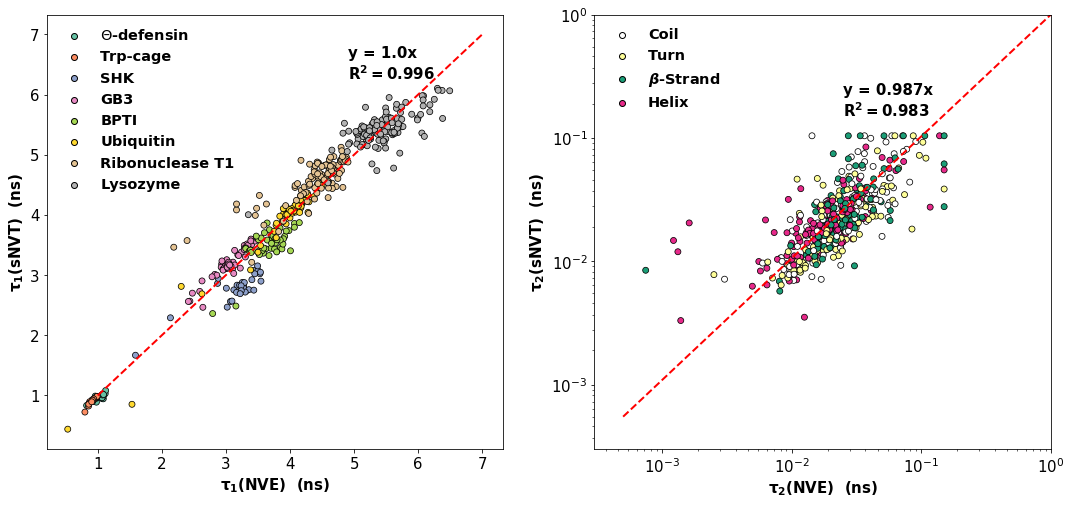

In [177]:
fig_CorrNVEsNVT, (axCorrT1, axCorrT2) = plt.subplots(1, 2, figsize=(18,8))

##Tau1 Plot

sns.scatterplot(x='NVE_t1', y='sNVT_t1', data=corrplotOrdered_DF, hue='ProtName', hue_order=prot_order,
                palette='Set2', ax=axCorrT1, edgecolor='k', alpha=1.0)
f5ss_hndlT1, f5ss_lblsT1 = axCorrT1.get_legend_handles_labels()
for hndl in f5ss_hndlT1[1:]:
        hndl.set_edgecolor('k')
axCorrT1.legend(f5ss_hndlT1[1:], f5ss_lblsT1[1:], loc=2, frameon=False, edgecolor='k', prop={'size':14.5, 'weight':'bold'})

axCorrT1.plot(np.arange(1,7.25,0.25), Fit_sNVT_NVE_T1.predict(np.arange(1,7.25,0.25)) , linestyle='--', linewidth=2, c='r')

axCorrT1.text(4.9, 6.25,'y = {:.3}x'.format(Fit_sNVT_NVE_T1.params[0])+'\n'+ r'$\mathbf{{R^{{2}} = {:.3}}}$'.format(Fit_sNVT_NVE_T1.rsquared),
             weight='bold',fontsize=15)

axCorrT1.set_ylabel(r'$\mathbf{\tau_{1}(sNVT) \ \ (ns)}$', fontsize=15)
axCorrT1.set_xlabel(r'$\mathbf{\tau_{1}(NVE) \ \ (ns)}$', fontsize=15)
axCorrT1.tick_params(labelsize=15)

## Tau2 Plot
sns.scatterplot(x='NVE_t2', y='sNVT_t2', data=corrplotdf, hue='SS', hue_order=['Coil','Turn',r'$\beta$-Strand','Helix'],
                    palette=SatYelSS_ColorPalette, ax=axCorrT2, edgecolor='k', alpha=1.0)
axCorrT2.plot(np.log10(np.arange(5e-4, 1e0, 0.5e-4)), Fit_sNVT_NVE_T2.predict(np.log10(np.arange(5e-4, 1e0, 0.5e-4))),
              linestyle='--', linewidth=2, c='r')

f5ss_hndl, f5ss_lbls = axCorrT2.get_legend_handles_labels()
for hndl in f5ss_hndl[1:]:
        hndl.set_edgecolor('k')
axCorrT2.legend(f5ss_hndl[1:], f5ss_lbls[1:], loc=2, frameon=False, edgecolor='k', prop={'size':14.5, 'weight':'bold'})
    
axCorrT2.text(np.log10(0.025), np.log10(0.15), 'y = {:3.3}x'.format(Fit_sNVT_NVE_T2.params[0])+'\n'+ r'$\mathbf{{R^{{2}} = {:.3}}}$'.format(Fit_sNVT_NVE_T2.rsquared),
             weight='bold', fontsize=15)
axCorrT2.set_ylabel(r'$\mathbf{\tau_{2}(sNVT) \ \ (ns)}$', fontsize=15)
axCorrT2.set_xlabel(r'$\mathbf{\tau_{2}(NVE) \ \ (ns)}$', fontsize=15)

axCorrT2.yaxis.set_ticks([np.log10(1e-3), np.log10(1e-2), np.log10(1e-1), np.log10(1e0)])
axCorrT2.yaxis.set_major_formatter(mticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
axCorrT2.yaxis.set_ticks([np.log10(x) for p in range(-4,0) for x in np.linspace(10**p, 10**(p+1), 11)], minor=True)

axCorrT2.xaxis.set_ticks([np.log10(1e-3), np.log10(1e-2), np.log10(1e-1), np.log10(1e0)])
axCorrT2.xaxis.set_major_formatter(mticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
axCorrT2.xaxis.set_ticks([np.log10(x) for p in range(-4,0) for x in np.linspace(10**p, 10**(p+1), 11)], minor=True)
axCorrT2.set_xlim(np.log10(3e-4), np.log10(1.0))
axCorrT2.set_ylim(np.log10(3e-4), np.log10(1.0))
axCorrT2.tick_params(labelsize=15)

fig_CorrNVEsNVT.savefig('{}Figure5_ScaleT1_T2_Paired2_newFits.png'.format(CorrFuncLoc2), dpi=600, bbox_inches='tight')

In [ ]:
sns.palplot(cm.)

## Figure 6: NMR Relaxation

In [ ]:
def _plot_NMRRelax(fitdf, nmr_expdf, nres, r1r2_lim, fsize=(8,10)):
    
    fignmr_err, axnmr_err = plt.subplots(2, 1, sharex=True,figsize=fsize)
    fignmr_err.subplots_adjust(hspace=0.025)
    RMSE_R1R2 = np.sqrt(fitdf.iloc[1:-1][['R1_SE','R2_SE','NOE_SE']].mean())
    
    ##R1 Plots 
    axR1 = axnmr_err[0]
    nmr_expdf[['RESID','R1']].plot(x='RESID', y='R1',ax=axR1, color='k',
                                    label=r'$\mathit{R}_\mathbf{1}$_Exp',
                                    linestyle='-', linewidth=2, marker='d')
        
    fitdf[['RESNUM','R1']].plot(x='RESNUM',y='R1', ax=axR1, color='teal', 
                                 label=r'$\mathit{{R}}_\mathbf{{1}}$-RMSE:{:.2}'.format(RMSE_R1R2['R1_SE']),
                                 linewidth=2, linestyle='-', marker='o')

    ## R2 Plots
    nmr_expdf[['RESID','R2']].plot(x='RESID', y='R2',ax=axR1, color='k',
                                    label=r'$\mathit{{R}}_\mathbf{{2}}$_Exp',
                                    linestyle='--', linewidth=2, marker='d')
        
    fitdf[['RESNUM','R2']].plot(x='RESNUM',y='R2', ax=axR1, color='#fb7d07',  
                                 label=r'$\mathit{{R}}_\mathbf{{2}}$-RMSE:{:.2}'.format(RMSE_R1R2['R2_SE']),
                                 linewidth=2, linestyle='--', marker='o')
    

    #axR2.text(1, 6.40, 'b', weight='bold',fontsize=18, ha='left',va='top')
    #axR1.set_ylabel(r'$\mathit{R}_\mathbf{2} \ \ (s^{-1})$', weight='bold', fontsize=15)
    #axR1.legend(frameon=False, loc='3', prop={'size':14,'weight':'bold'})
    axR1.set_ylim(r1r2_lim[0], r1r2_lim[1])
    axR1.set_ylabel(r'$\mathit{R}_\mathbf{1,2} \ \ (s^{-1})$', weight='bold', fontsize=15)
    axR1.legend(frameon=False, ncol=2, mode='expand', loc='upper left', prop={'size':14,'weight':'bold'})
    axR1.tick_params(labelsize=14)
    
    ## NOE Plots
    axNOE = axnmr_err[1]
    nmr_expdf[['RESID','NOE']].plot(x='RESID', y='NOE', ax=axNOE, color='k',
                                             label='NOE_Exp',
                                    linestyle='-',ylim=(0.0,1.0), linewidth=2, marker='d')

        
    fitdf[['RESNUM','NOE']].plot(x='RESNUM',y='NOE', ax=axNOE, color='green',
                                  label='NOE-RMSE:{:.1}'.format(RMSE_R1R2['NOE_SE']),
                                  linewidth=2, linestyle='-' , marker='o')


    #axNOE.text(1,0.95,'c', weight='bold',fontsize=18, ha='left',va='top')
    axNOE.set_ylabel(r'$\mathbf{^{1}H-^{15}N}$ Het. NOE', weight='bold', fontsize=15)
    axNOE.set_xlabel('Residue Number', weight='bold', fontsize=15)
    axNOE.set_xlim(0, nres+1)
    axNOE.legend(frameon=False, prop={'size':14,'weight':'bold'})
    axNOE.set_xticks(np.arange(0, nres, 10))
    axNOE.set_xticks(np.arange(0, nres, 5), minor=True)
    axNOE.set_xticklabels(np.arange(0, nres, 10))
    axNOE.tick_params(labelsize=14)
    
    return fignmr_err

In [ ]:
def J_direct_transform(om, consts, taus):
    
    ## Calculation for the direct spectral density 
    ndecay=len(consts) ; noms=1;###lnden(om)
    Jmat = np.zeros( (ndecay, noms ) )
    
    for i in range(ndecay):
        
        Jmat[i] = consts[i]*(taus[i]*1e-9)/(
            1 + np.power((taus[i]*1e-9)*(om),2.))
        
    return Jmat.sum(axis=0)

In [ ]:
def calc_NMR_Relax(J, fdd, fcsa, gammaH, gammaN):
    
    R1 = fdd * (J['Diff'] + 3*J['15N'] + 6*J['Sum']) + fcsa * J['15N']
    
    R2 = (0.5 * fdd * (4*J['0'] + J['Diff'] + 3*J['15N'] + 6*J['1H'] + 6*J['Sum']) 
          + (1./6.) * fcsa*(4*J['0'] + 3*J['15N']) )
    
    NOE = 1 + ((fdd*gammaH)/(gammaN*R1))*(6*J['Sum'] - J['Diff'])
    
    return R1, R2, NOE

In [ ]:
def TauScaleFunction(t, z):
    
    dfscale_params = pd.DataFrame(data=[[0.2, 1.01, 0.0273], [2, 1.4322, 0.0667], [20, 4.3661, 0.1115]],
                            columns=[r'$\zeta$', 'a', 'b']).set_index(r'$\zeta$')
    
    a = dfscale_params.loc[z, 'a']
    b = dfscale_params.loc[z, 'b']
    
    return t/(a + b*t)

    

In [ ]:
def ScaleNMRParams(fit_nmrdf, exp_nmrdf, magfield, coupling=0.2):
    
    ## Parameters and Physical Constants for calculation of Relaxation Rates
    H_gyro = 2*np.pi*42.57748*1e6     ## Gyromagnetic Ratio: Hydrogen ([rad]/[s][T]) 
    N_gyro = -2*np.pi*4.317267*1e6     ## Gyromagnetic Ratio: Nitrogen ([rad]/[s][T])
    B0 = 2*np.pi*magfield*1e6/H_gyro   ## Field Strength = 18.8 Teslas

    ## Need 5 Frequencies: ## J[0], J[wH], J[wN], J[wH-wN], J[wH+wN]
    Larmor1H = H_gyro*B0              ## Larmor Frequency: Hydrogen ([rad]/[s])
    Larmor15N = N_gyro*B0             ## Larmor Frequency: Hydrogen ([rad]/[s])
    omDiff = Larmor1H - Larmor15N    ## Diff in Larmor Frequencies of Spin IS
    omSum  = Larmor1H + Larmor15N    ## Sum of Larmor Frequencies of Spin I
    
    mu_0 = 4*np.pi*1e-7    ; ## H/m
    hbar = 1.0545718e-34  ; # [J] * [s] = [kg] * [m^2] * [s^-1] 
    R_NH = 1.02e-10                     ## distance between N-H atoms in Angstroms
    dSigmaN = -170e-6 
    
    FDD = (1./10.)*np.power((mu_0*hbar*H_gyro*N_gyro)/(4*np.pi*np.power(R_NH,3)),2)
    FCSA = (2.0/15.0)*(Larmor15N**2)*(dSigmaN**2)  
    
    NMRRelax_Scl = fit_nmrdf.copy()
    
    print('Scaling all correlation times by predefined scaling parameters')
        
    NMRRelax_Scl['tau_a'] = NMRRelax_Scl['tau_a'].apply(TauScaleFunction, args = (coupling, ))
    NMRRelax_Scl['tau_b'] = NMRRelax_Scl['tau_b'].apply(lambda tau: TauScaleFunction(tau, 2) if np.log10(tau - 5e-4) < -20.0 else tau) 
    
    NMRRelax_Scl['AUC_a'] = NMRRelax_Scl['tau_a']*NMRRelax_Scl['C_a']
    NMRRelax_Scl['AUC_b'] = NMRRelax_Scl['tau_b']*NMRRelax_Scl['C_b']
    NMRRelax_Scl['AUC_Total'] = NMRRelax_Scl[['AUC_a','AUC_b','AUC_g','AUC_d']].sum(axis=1)   

    for i,fit in NMRRelax_Scl.iterrows():
        c = fit[['C_a','C_b','C_g','C_d']].values
        t = fit[['tau_a','tau_b','tau_g','tau_d']].values
        Jdict = {'0':0, '1H':0,'15N':0,'Sum':0,'Diff':0} 
        J0 = J_direct_transform(0, c, t)
        JH = J_direct_transform(Larmor1H, c, t)
        JN = J_direct_transform(Larmor15N, c, t)
        JSum = J_direct_transform(omSum,  c, t)
        JDiff = J_direct_transform(omDiff,  c, t)
        Jdict['1H'] = JH ; Jdict['15N'] = JN; Jdict['0'] = J0; 
        Jdict['Sum'] = JSum; Jdict['Diff'] = JDiff;
        r1, r2, noe = calc_NMR_Relax(Jdict, FDD, FCSA, H_gyro, N_gyro)
        NMRRelax_Scl.loc[i, 'T1'] = 1/r1
        NMRRelax_Scl.loc[i, 'R1'] = r1
        NMRRelax_Scl.loc[i, 'T2'] = 1/r2
        NMRRelax_Scl.loc[i, 'R2'] = r2
        NMRRelax_Scl.loc[i, 'NOE'] = noe
        
        
    RMSE_DF = pd.DataFrame(index=NMRRelax_Scl['Resname'],
                               columns = ['{}_SE'.format(nmr) for nmr in ['R1','T1','R2','T2','NOE']])
    NMRRelax_Scl = NMRRelax_Scl.drop(columns = RMSE_DF.columns)
    for nmr in ['R1','T1','R2','T2','NOE']:
        RMSE_DF['{}_SE'.format(nmr)] = (NMRRelax_Scl[['Resname', nmr]].set_index('Resname') - 
                                            exp_nmrdf.rename(columns={'RESID':'Resname'})[['Resname',nmr]].set_index('Resname'))**2
    NMRRelax_Scl = NMRRelax_Scl.merge(RMSE_DF.reset_index(), how='left', left_on='Resname', right_on='Resname')    

    return NMRRelax_Scl
       

In [ ]:
NMRRelax_FitDF_GB3_NVT_2ps['tau_b'].apply(lambda tau: TauScaleFunction(tau, 2) if np.log10(tau - 5e-4) < -20.0 else tau)

In [ ]:
np.log10(NMRRelax_FitDF_GB3_NVT_2ps.loc[3,'tau_b'] - 5e-4)

In [ ]:
NMRRelax_FitDF_GB3_NVT_2ps.loc[3,'tau_b']

In [ ]:
GB3_NMRRelax_Exp = pd.read_csv('{}{}/GB3_NMRRelax_Experiment.csv'.format(CorrFuncLoc2,'GB3'), index_col=0)
UBQ_NMRRelax_Exp = pd.read_csv('{}{}/UBQ_NMRRelax_Experiment.csv'.format(CorrFuncLoc2,'Ubiquitin'), index_col=0)

In [ ]:
GB3_sNVT_NMRRelax = ScaleNMRParams(NMRRelax_FitDF_GB3_NVT_2ps, GB3_NMRRelax_Exp, 600, coupling=2)

In [ ]:
UBQ_sNVT_NMRRelax = ScaleNMRParams(NMRRelax_FitDF_UBQ_NVT_2ps, UBQ_NMRRelax_Exp, 600, coupling=2)

In [ ]:
GB3_sNVT_NMRRelax_20ps = ScaleNMRParams(NMRRelax_FitDF_GB3_NVT_20ps, GB3_NMRRelax_Exp, 600, coupling=20)
UBQ_sNVT_NMRRelax_20ps = ScaleNMRParams(NMRRelax_FitDF_UBQ_NVT_20ps, UBQ_NMRRelax_Exp, 600, coupling=20)

In [ ]:
UBQ_sNVT_NMRRelax.iloc[-1]['Resname']

In [ ]:
GB3atom_df.shape, UBQatom_df.shape

In [ ]:

figNMR_Err, axNMR_Err = plt.subplots(3, 1, sharex=True, figsize=(8,12))
figNMR_Err.subplots_adjust(hspace=0.025)
RMSE_R1R2 = np.sqrt(NMRRelax_FitDF_GB3_NVE.iloc[1:-1][['R1_SE','R2_SE','NOE_SE']].mean())
##R1 Plots 
axR1 = axNMR_Err[0]
NMRRelax_FitDF_GB3_NVE[['RESNUM','R1']].plot(x='RESNUM',y='R1', ax=axR1, color='teal', 
                                 label=r'$\mathit{{R}}_\mathbf{{1}}$-RMSE:{:.2}'.format(RMSE_R1R2['R1_SE']),
                                 linewidth=2, linestyle='-', marker='o')
GB3_NMRRelax_Exp[['RESID','R1']].plot(x='RESID', y='R1',ax=axR1, color='k',
                                                label=r'$\mathit{R}_\mathbf{1}$_Exp',
                                                linestyle='-', linewidth=2, marker='d')

axR1.set_ylim(1.5, 3.0)
axR1.text(1,2.90,'a', weight='bold',fontsize=18, ha='left',va='top')
axR1.set_ylabel(r'$\mathit{R}_\mathbf{1} \ \ (s^{-1})$', weight='bold', fontsize=15)
axR1.legend(frameon=False, loc=4, prop={'size':14,'weight':'bold'})
axR1.tick_params(labelsize=14)

## R2 Plots
axR2 = axNMR_Err[1]

GB3_NMRRelax_Exp[['RESID','R2']].plot(x='RESID', y='R2',ax=axR2, color='k',
                                                label=r'$\mathit{{R}}_\mathbf{{2}}$_Exp',
                                                linestyle='-', linewidth=2, marker='d')

NMRRelax_FitDF_GB3_NVE[['RESNUM','R2']].plot(x='RESNUM',y='R2', ax=axR2, color='#fb7d07',  
                                 label=r'$\mathit{{R}}_\mathbf{{2}}$-RMSE:{:.2}'.format(RMSE_R1R2['R2_SE']),
                                 linewidth=2, linestyle='-', marker='o')

axR2.text(1,6.40,'b', weight='bold',fontsize=18, ha='left',va='top')
axR2.set_ylabel(r'$\mathit{R}_\mathbf{2} \ \ (s^{-1})$', weight='bold', fontsize=15)
axR2.legend(frameon=False, loc='best', prop={'size':14,'weight':'bold'})
axR2.tick_params(labelsize=14)
axR2.set_ylim(2.5,6.5)
#axR2.set_yticks([3.0, 4.0, 5.0, 6.0])
#axR2.set_yticklabels([3.0, 4.0, 5.0, 6.0])

## NOE Plots
axNOE = axNMR_Err[2]
NMRRelax_FitDF_GB3_NVE[['RESNUM','NOE']].plot(x='RESNUM',y='NOE', ax=axNOE, color='green',
                                  label='NOE-RMSE:{:.1}'.format(RMSE_R1R2['NOE_SE']),
                                  linewidth=2, linestyle='-' , marker='o')
GB3_NMRRelax_Exp[['RESID','NOE']].plot(x='RESID', y='NOE', ax=axNOE, color='k',
                                                 label='NOE_Exp',
                                                  linestyle='-',ylim=(0.0,1.0), linewidth=2, marker='d')


axNOE.text(1,0.95,'c', weight='bold',fontsize=18, ha='left',va='top')
axNOE.set_ylabel(r'$\mathbf{^{1}H-^{15}N}$ Het. NOE', weight='bold', fontsize=15)
axNOE.set_xlabel('Residue Number', weight='bold', fontsize=15)
axNOE.set_xlim(0,57)
axNOE.legend(frameon=False,prop={'size':14,'weight':'bold'})
axNOE.set_xticks(np.arange(1,57,5))
axNOE.set_xticklabels(np.arange(1,57,5))
axNOE.tick_params(labelsize=14)

figNMR_Err.savefig('{}{}/Analysis/NMRRelax_GB3_Prod_NVE_OptSim_NewFits.png'.format(CorrFuncLoc2,'GB3'),
              bbox_inches='tight',dpi=600)

In [ ]:
fig_NMR_NVEV = _plot_NMRRelax(NMRRelax_FitDF_GB3_NVE, GB3_NMRRelax_Exp, 56, (1.5,7.0))
fig_NMR_NVEV.savefig('{}{}/Analysis/Figure5_NMRRelax_NVE_R1R2SameAx_NewFits.png'.format(CorrFuncLoc2,'GB3'), dpi=600, bbox_inches='tight')

In [ ]:
fig_NMR_sNVTCf2ps = _plot_NMRRelax(GB3_sNVT_NMRRelax, GB3_NMRRelax_Exp, 56, (1.5,7.0))
fig_NMR_sNVTCf2ps.savefig('{}{}/Analysis/Figure5_NMRRelax_sNVT_CF2ps_R1R2SameAx_NewFits.png'.format(CorrFuncLoc2,'GB3'), dpi=600, bbox_inches='tight')

In [ ]:
fig_NMR_sNVTCf20ps = _plot_NMRRelax(GB3_sNVT_NMRRelax_20ps, GB3_NMRRelax_Exp, 56, (1.5,7.0))
fig_NMR_sNVTCf20ps.savefig('{}{}/Analysis/Figure5_NMRRelax_sNVT_CF20ps_R1R2SameAx_NewFits.png'.format(CorrFuncLoc2,'GB3'), dpi=600, bbox_inches='tight')

In [ ]:
## Figure S2: Order Parameters 

In [ ]:
NMRRelax_FitDF_UBQ_NVE

In [ ]:
fig_NMR_ubq_nve = _plot_NMRRelax(NMRRelax_FitDF_UBQ_NVE, UBQ_NMRRelax_Exp, 76, (0.5, 10), fsize=(10,12))
fig_NMR_ubq_nve.savefig('{}{}/Analysis/Figure5_NMRRelax_Ubiquitin_NVE_R1R2SameAx_NewFits.png'.format(CorrFuncLoc2, 'Ubiquitin'), dpi=600, bbox_inches='tight')

In [ ]:
fig_NMR_ubq_snvt = _plot_NMRRelax(UBQ_sNVT_NMRRelax, UBQ_NMRRelax_Exp, 76, (0.5, 10), fsize=(10,12))
fig_NMR_ubq_snvt.savefig('{}{}/Analysis/Figure5_NMRRelax_Ubiquitin_sNVT_CF2ps_NewFits.png'.format(CorrFuncLoc2, 'Ubiquitin'), dpi=600, bbox_inches='tight')

In [ ]:
fig_NMR_ubq_snvt_20 = _plot_NMRRelax(UBQ_sNVT_NMRRelax_20ps, UBQ_NMRRelax_Exp, 76, (0.5, 10), fsize=(10,12))
fig_NMR_ubq_snvt_20.savefig('{}{}/Analysis/Figure5_NMRRelax_Ubiquitin_sNVT_CF20ps_NewFits.png'.format(CorrFuncLoc2, 'Ubiquitin'), dpi=600, bbox_inches='tight')

## Beginning Supplemental Figures
### Figure S2 : Order Parameters


In [30]:
def read_OrderParameterFiles(atom_df, prot, ens, gamma = 'CF2ps'):
    
    """
    Function to read the order parameters functions calculated from cpptraj and python script 
    
    """
    
    resS2df = pd.DataFrame(index=atom_df.iloc[1:]['RESID'], columns=RUNS)
    resS2df_STD = resS2df.copy()
    for R in RUNS:
            
        if ens == 'NVE':
            s2df = pd.read_csv('{}/OrderParameter_Direct.csv'.format(LocDF_NVE.loc[R,(prot, ens)]),
                                                                         names=['RESN',r'$S^{2}$'])
        elif ens =='NVT':
            s2df = pd.read_csv('{}/OrderParameter_Direct.csv'.format(LocDF_NVT.loc[R,(prot, gamma)]),
                                   names=['RESN',r'$S^{2}$'])

        resS2df.loc[:,R] = s2df[r'$S^{2}$'].values
            
    return resS2df

In [31]:
def read_BlockOrderParameterFiles(locdf, atom_df, prot, ens, gamma='CF2ps'):
    
    """
    Function to read the order parameters functions calculated from cpptraj and python script 
    
    """
    
    resS2df = pd.DataFrame(index=atom_df.iloc[1:]['RESID'], columns=RUNS)
    resS2df_STD = resS2df.copy()
    for R in RUNS:
            
        if ens == 'NVE':
            s2df = pd.read_csv('{}/Block_OrderParameters_1ns.csv'.format(locdf.loc[R,(prot, ens)]), index_col=0)
        elif ens =='NVT':
            s2df = pd.read_csv('{}/Block_OrderParameters_1ns.csv'.format(locdf.loc[R,(prot, gamma)]), index_col=0)
            
        s2df.columns = s2df.columns.astype(int)
        resS2df.loc[s2df.columns, R] = s2df.mean()
        resS2df_STD.loc[s2df.columns, R] = s2df.std()
        
    return resS2df, resS2df_STD


In [ ]:
s2df = pd.read_csv('{}/Block_OrderParameters_1ns.csv'.format(LocDF_NVE_R2.loc['Run1',('GB3', 'NVE')]), index_col=0)

In [ ]:
LocDF_NVT

In [32]:
def _load_Experimental_Results(protein, prot_topology, min_thresh=0.4):
    

    CAInd = prot_topology.select('name CA and protein')
    CAatom_name = pd.Series(['{}'.format(prot_topology.atom(atmx)) for atmx in CAInd])
    atom_df = CAatom_name.str.split('-',expand=True).rename(columns={0:'RESNAME',1:'ATMNAME'})
    atom_df['RESNAME'] = atom_df['RESNAME'].apply(lambda rr: '{}'.format(rr[:3] + str(int(rr[3:])+1)))
    atom_df['RESID'] = atom_df['RESNAME'].apply(lambda rr: int(rr[3:]))
    
    exp_nmr_df = pd.DataFrame(index=np.arange(0,len(atom_df),1), columns=['RESNAME','RESID', 'S2'])
    exp_nmr_df['RESNAME'] = atom_df['RESNAME']
    exp_nmr_df['RESID'] = atom_df['RESID'].astype('int64')
    
    nmrdf = pd.read_csv('{}{}/{}_{}_Experiment_Capture_AllPoints.csv'.format(CorrFuncLoc2, protein, protein, 'S2'),
                            header=None, names=['BarNumber', 'S2'])
    exp_nmr_df['S2'] = nmrdf['S2'].values
    
    mask_noexp = nmrdf['S2'] < min_thresh
    exp_nmr_df.loc[mask_noexp,'S2'] = np.nan
    
    return exp_nmr_df

In [ ]:
def _plot_OrderParameters():

In [33]:
GB3_EXPS2 = _load_Experimental_Results('GB3', GB3Top, min_thresh=0.4)

NameError: name 'GB3Top' is not defined

In [132]:
GB3_S2_NVE = read_OrderParameterFiles(GB3atom_df, 'GB3', 'NVE', gamma='CF2ps')
GB3_S2_CF2ps = read_OrderParameterFiles(GB3atom_df, 'GB3','NVT', gamma='CF2ps')
GB3_S2_CF02ps = read_OrderParameterFiles(GB3atom_df, 'GB3','NVT', gamma='CF0-2ps')
GB3_S2_CF20ps = read_OrderParameterFiles(GB3atom_df, 'GB3','NVT', gamma='CF20ps')

In [133]:
GB3_NVER1_BS2, GB3_NVER1_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVE, GB3atom_df, 'GB3','NVE')
GB3_NVER2_BS2, GB3_NVER2_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVE_R2, GB3atom_df, 'GB3','NVE')

GB3_NVT_CF02ps_BS2, GB3_NVT_CF02ps_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVT, GB3atom_df,
                                                                           'GB3','NVT', gamma='CF0-2ps')
GB3_NVT_CF2ps_BS2, GB3_NVT_CF2ps_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVT, GB3atom_df,
                                                                           'GB3','NVT', gamma='CF2ps')
GB3_NVT_CF20ps_BS2, GB3_NVT_CF20ps_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVT, GB3atom_df,
                                                                           'GB3','NVT', gamma='CF20ps')

In [134]:
GB3_OPTNVE_BS2  = GB3_NVER1_BS2.copy()
GB3_OPTNVE_BS2_STD = GB3_NVER1_BS2_STD.copy()

GB3_OPTNVE_BS2['Run1'] = GB3_NVER1_BS2['Run3']
GB3_OPTNVE_BS2['Run2'] = GB3_NVER1_BS2['Run4']
GB3_OPTNVE_BS2['Run3'] = GB3_NVER2_BS2['Run2']
GB3_OPTNVE_BS2['Run4'] = GB3_NVER2_BS2['Run3']

GB3_OPTNVE_BS2_STD['Run1'] = GB3_NVER1_BS2_STD['Run3']
GB3_OPTNVE_BS2_STD['Run2'] = GB3_NVER1_BS2_STD['Run4']
GB3_OPTNVE_BS2_STD['Run3'] = GB3_NVER2_BS2_STD['Run2']
GB3_OPTNVE_BS2_STD['Run4'] = GB3_NVER2_BS2_STD['Run3']


In [37]:
UBQ_NVER1_BS2, UBQ_NVER1_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVE, UBQatom_df, 'Ubiquitin','NVE')
UBQ_NVER2_BS2, UBQ_NVER2_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVE_R2, UBQatom_df, 'Ubiquitin','NVE')

UBQ_NVT_CF02ps_BS2, UBQ_NVT_CF02ps_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVT, UBQatom_df,
                                                                           'Ubiquitin','NVT', gamma='CF0-2ps')
UBQ_NVT_CF2ps_BS2, UBQ_NVT_CF2ps_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVT, UBQatom_df,
                                                                           'Ubiquitin','NVT', gamma='CF2ps')
UBQ_NVT_CF20ps_BS2, UBQ_NVT_CF20ps_BS2_STD = read_BlockOrderParameterFiles(LocDF_NVT, UBQatom_df,
                                                                           'Ubiquitin','NVT', gamma='CF20ps')

FileNotFoundError: [Errno 2] File b'E:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE/Run1/Block_OrderParameters_1ns.csv' does not exist: b'E:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE/Run1/Block_OrderParameters_1ns.csv'

In [136]:
UBQ_OPTNVE_BS2  = UBQ_NVER1_BS2.copy()
UBQ_OPTNVE_BS2_STD = UBQ_NVER1_BS2.copy()

UBQ_OPTNVE_BS2['Run1'] = UBQ_NVER1_BS2['Run3']
UBQ_OPTNVE_BS2['Run2'] = UBQ_NVER1_BS2['Run4']
UBQ_OPTNVE_BS2['Run3'] = UBQ_NVER2_BS2['Run2']
UBQ_OPTNVE_BS2['Run4'] = UBQ_NVER2_BS2['Run3']

UBQ_OPTNVE_BS2_STD['Run1'] = UBQ_NVER1_BS2_STD['Run1']
UBQ_OPTNVE_BS2_STD['Run2'] = UBQ_NVER1_BS2_STD['Run2']
UBQ_OPTNVE_BS2_STD['Run3'] = UBQ_NVER2_BS2_STD['Run1']
UBQ_OPTNVE_BS2_STD['Run4'] = UBQ_NVER2_BS2_STD['Run3']


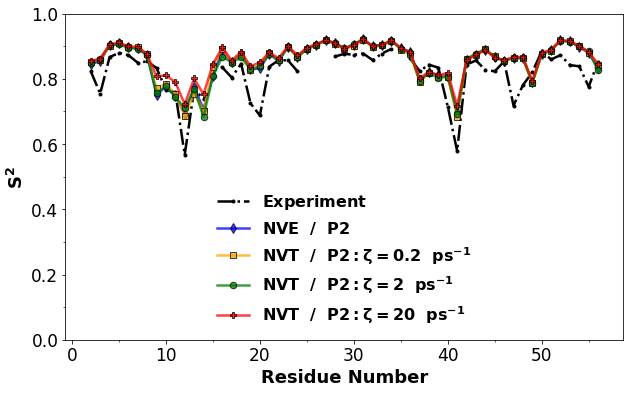

In [137]:
figS2GB3 = plt.figure(3280, figsize=(10,6))
axS2gb3 = figS2GB3.add_subplot(111)

GB3_EXPS2.plot(x='RESID',y='S2', color='k', style='-..',
                                          label=r'$\mathbf{Experiment}$',
                                          ax=axS2gb3, linewidth=2.5)

GB3_OPTNVE_BS2.mean(axis=1).plot(style='-d', color='b', markeredgecolor='k', ax=axS2gb3,
                            label = r'$\mathbf{NVE \ \ / \ \ P2}$',
                             linewidth=2.5, markersize=6.5, alpha=0.75)
GB3_NVT_CF02ps_BS2.mean(axis=1).plot(style='-s', color='orange', markeredgecolor='k', ax=axS2gb3,
                               label = r'$\mathbf{NVT \ \ / \ \ P2 : \zeta = 0.2 \ \ ps^{-1}}$',
                                linewidth=2.5, markersize=6.5, alpha=0.75)
GB3_NVT_CF2ps_BS2.mean(axis=1).plot(style='-o',  color='green', markeredgecolor='k', ax=axS2gb3,
                              label = r'$\mathbf{NVT \ \ / \ \ P2 : \zeta = 2 \ \ ps^{-1}}$',
                               linewidth=2.5, markersize=6.5, alpha=0.75)
GB3_NVT_CF20ps_BS2.mean(axis=1).plot(style='-P', color='red', markeredgecolor='k', ax=axS2gb3,
                               label = r'$\mathbf{NVT \ \ / \ \ P2 : \zeta = 20 \ \ ps^{-1}}$',
                                linewidth=2.5, markersize=6.5, alpha=0.75)

axS2gb3.set_ylabel(r'$\mathbf{S^2}$', fontsize=18)
axS2gb3.set_xlabel(r'Residue Number', fontsize=18, weight='bold')
axS2gb3.tick_params(labelsize=17)
axS2gb3.set_xticks(np.arange(0,60,5), minor=True)
axS2gb3.set_yticks(np.arange(0,1.1,0.1), minor=True)
axS2gb3.legend(frameon=False, loc=8, prop={'size':16})

figS2GB3.savefig('{}{}/Analysis/FigureS2_GB3_OrderParametersDirect_AllSims_CompareExp_Block.png'.format(CorrFuncLoc2, 'GB3'),
                 dpi=600, bbox_inches='tight')


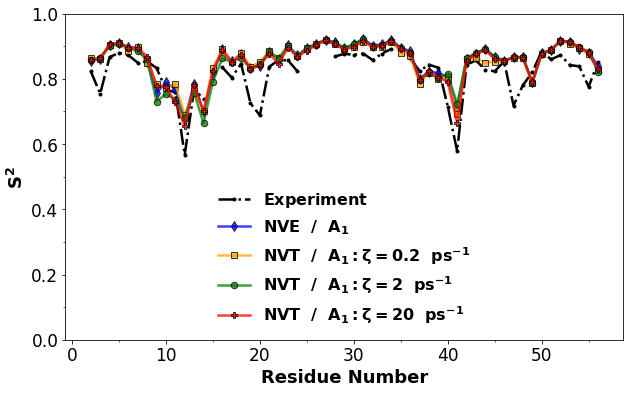

In [178]:
figS2GB3 = plt.figure(3280, figsize=(10,6))
axS2gb3 = figS2GB3.add_subplot(111)

GB3_EXPS2.plot(x='RESID',y='S2', color='k', style='-..',
                                          label=r'$\mathbf{Experiment}$',
                                          ax=axS2gb3, linewidth=2.5)

NMRRelax_FitDF_GB3_NVE.plot(x='Resname', y='C_a', style='-d', color='b', markeredgecolor='k', ax=axS2gb3,
                            label = r'$\mathbf{NVE \ \ / \ \ A_{1}}$',
                             linewidth=2.5, markersize=6.5, alpha=0.75)
NMRRelax_FitDF_GB3_NVT_02ps.plot(x='Resname', y='C_a', style='-s', color='orange', markeredgecolor='k', ax=axS2gb3,
                               label = r'$\mathbf{NVT \ \ / \ \ A_{1} : \zeta = 0.2 \ \ ps^{-1}}$',
                                linewidth=2.5, markersize=6.5, alpha=0.75)
NMRRelax_FitDF_GB3_NVT_2ps.plot(x='Resname', y='C_a', style='-o',  color='green', markeredgecolor='k', ax=axS2gb3,
                              label = r'$\mathbf{NVT \ \ / \ \ A_{1} : \zeta = 2 \ \ ps^{-1}}$',
                               linewidth=2.5, markersize=6.5, alpha=0.75)
NMRRelax_FitDF_GB3_NVT_20ps.plot(x='Resname', y='C_a', style='-P', color='red', markeredgecolor='k', ax=axS2gb3,
                               label = r'$\mathbf{NVT \ \ / \ \ A_{1} : \zeta = 20 \ \ ps^{-1}}$',
                                linewidth=2.5, markersize=6.5, alpha=0.75)

axS2gb3.set_ylabel(r'$\mathbf{S^2}$', fontsize=18)
axS2gb3.set_xlabel(r'Residue Number', fontsize=18, weight='bold')
axS2gb3.tick_params(labelsize=17)
axS2gb3.set_xticks(np.arange(0,60,5), minor=True)
axS2gb3.set_yticks(np.arange(0,1.1,0.1), minor=True)
axS2gb3.legend(frameon=False, loc=8, prop={'size':16})

figS2GB3.savefig('{}{}/Analysis/FigureS2_GB3_A1CompareExp_AllSims.png'.format(CorrFuncLoc2, 'GB3'),
                 dpi=600, bbox_inches='tight')


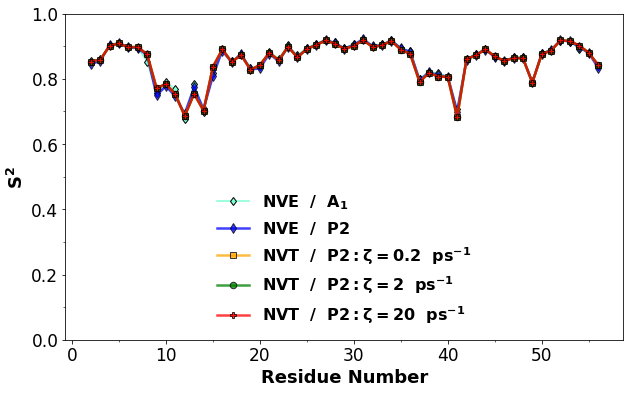

In [207]:
figS2GB3 = plt.figure(3285, figsize=(10,6))
axS2gb3 = figS2GB3.add_subplot(111)

#GB3_EXPS2.plot(x='RESID', y='S2', color='k', style='-..',
#                                          label=r'$\mathbf{Experiment}$',
#                                          ax=axS2gb3, linewidth=2.5)

NMRRelax_FitDF_GB3_NVE.plot(x='Resname', y='C_a', color='aquamarine', ax=axS2gb3, 
                            marker='d', label=r'$\mathbf{NVE \ \ / \ \ A_{1}}$', markeredgecolor='k')

GB3_OPTNVE_BS2.mean(axis=1).plot(style='-d', color='b', markeredgecolor='k', ax=axS2gb3,
                            label = r'$\mathbf{NVE \ \ / \ \ P2}$',
                             linewidth=2.5, markersize=6.5, alpha=0.75)

GB3_NVT_CF02ps_BS2.mean(axis=1).plot(style='-s', color='orange', markeredgecolor='k', ax=axS2gb3,
                               label = r'$\mathbf{NVT \ \ / \ \ P2: \zeta = 0.2 \ \ ps^{-1}}$',
                                linewidth=2.5, markersize=6.5, alpha=0.75)
GB3_NVT_CF02ps_BS2.mean(axis=1).plot(style='-o',  color='green', markeredgecolor='k', ax=axS2gb3,
                              label = r'$\mathbf{NVT \ \ / \ \ P2: \zeta = 2 \ \ ps^{-1}}$',
                               linewidth=2.5, markersize=6.5, alpha=0.75)
GB3_NVT_CF02ps_BS2.mean(axis=1).plot(style='-P', color='red', markeredgecolor='k', ax=axS2gb3,
                               label = r'$\mathbf{NVT \ \ / \ \ P2: \zeta = 20 \ \ ps^{-1}}$',
                                linewidth=2.5, markersize=6.5, alpha=0.75)

axS2gb3.set_ylabel(r'$\mathbf{S^2}$', fontsize=18)
axS2gb3.set_xlabel(r'Residue Number', fontsize=18, weight='bold')
axS2gb3.tick_params(labelsize=17)
axS2gb3.set_xticks(np.arange(0,60,5), minor=True)
axS2gb3.set_yticks(np.arange(0,1.1,0.1), minor=True)
axS2gb3.legend(frameon=False, loc=8, prop={'size':16})

figS2GB3.savefig('{}{}/Analysis/FigureS9_GB3_OrderParameters_Block_P2vsA1_AllSims.png'.format(CorrFuncLoc2, 'GB3'),
                 dpi=600, bbox_inches='tight')


In [38]:
UBQNHInd = UBQTop.select('name H and protein')
UBQNHatom_name = pd.Series(['{}'.format(UBQTop.atom(atmx)) for atmx in UBQNHInd])
UBQNHatom_df = UBQNHatom_name.str.split('-',expand=True).rename(columns={0:'RESNAME',1:'ATMNAME'})
UBQNHatom_df['RESNAME'] = UBQNHatom_df['RESNAME'].apply(lambda rr: '{}'.format(rr[:3] + str(int(rr[3:])+1)))
UBQNHatom_df['RESID'] = UBQNHatom_df['RESNAME'].apply(lambda rr: int(rr[3:]))

In [85]:


UBQ_S2_NVE = read_OrderParameterFiles(UBQNHatom_df, 'Ubiquitin','NVE', gamma='CF2ps')
UBQ_S2_CF2ps = read_OrderParameterFiles(UBQNHatom_df, 'Ubiquitin','NVT', gamma='CF2ps')
UBQ_S2_CF02ps = read_OrderParameterFiles(UBQNHatom_df, 'Ubiquitin','NVT', gamma='CF0-2ps')
UBQ_S2_CF20ps = read_OrderParameterFiles(UBQNHatom_df, 'Ubiquitin','NVT', gamma='CF20ps')

In [ ]:
NMRRelax_FitDF_UBQ_NVT_2ps.loc[45]

In [39]:
UBQ_NMRRelax_EXPFromSI = pd.read_excel('{}{}/ExpNMRRelaxation_1995_TjandraSI.xlsx'.format(CorrFuncLoc2,'Ubiquitin'))
UBQ_NMRRelax_Exp = pd.DataFrame(index=UBQ_NMRRelax_EXPFromSI.index, columns=['R1','T1','R2','T2','NOE','S2_iso'])

UBQ_NMRRelax_Exp['RESNAME'] = UBQ_NMRRelax_EXPFromSI['RESNAME']
UBQ_NMRRelax_Exp['RESID'] = UBQ_NMRRelax_Exp['RESNAME'].apply(lambda x: x[1:]).astype('int64')
UBQ_NMRRelax_Exp['T1'] = UBQ_NMRRelax_EXPFromSI[['T1,1','T1,2']].mean(axis=1)
UBQ_NMRRelax_Exp['R1'] = 1/UBQ_NMRRelax_Exp['T1']
UBQ_NMRRelax_Exp['T2'] = UBQ_NMRRelax_EXPFromSI[['T2,1','T2,2']].mean(axis=1)
UBQ_NMRRelax_Exp['R2'] = 1/UBQ_NMRRelax_Exp['T2']
UBQ_NMRRelax_Exp['NOE'] = UBQ_NMRRelax_EXPFromSI[['NOE,1','NOE,2']].mean(axis=1)
UBQ_NMRRelax_Exp['S2_iso'] = UBQ_NMRRelax_EXPFromSI['S2_iso']

In [ ]:
UBQ_S2_CF2ps.mean(axis=1).loc[[13,28,50]]

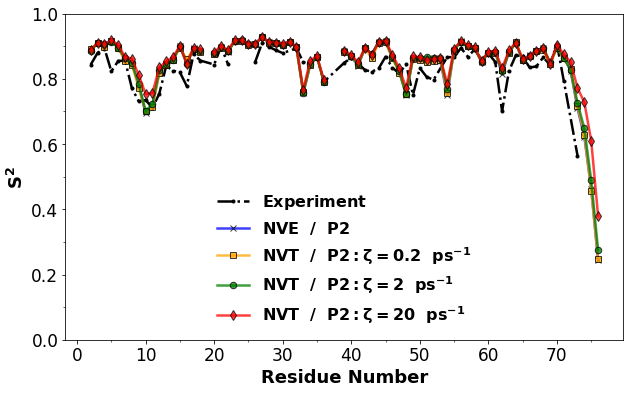

In [141]:
figS2UBQ = plt.figure(3281, figsize=(10,6))
axS2ubq = figS2UBQ.add_subplot(111)

UBQ_NMRRelax_Exp[['RESID','S2_iso']].plot(x='RESID',y='S2_iso', color='k', style='-..',
                                          label=r'$\mathbf{Experiment}$',
                                          ax=axS2ubq, linewidth=2.5)

UBQ_OPTNVE_BS2.mean(axis=1).plot( style='-x', color='blue', markeredgecolor='k',
                                label = r'$\mathbf{NVE \ \ / \ \ P2}$',
                                ax = axS2ubq, linewidth=2.5, markersize=6.5, alpha=0.75)

UBQ_NVT_CF02ps_BS2.mean(axis=1).plot(style='-s', color='orange', markeredgecolor='k',
                                label = r'$\mathbf{NVT \ \ / \ \ P2: \zeta = 0.2 \ \ ps^{-1}}$',
                                ax = axS2ubq, linewidth=2.5, markersize=6.5, alpha=0.75)

UBQ_NVT_CF2ps_BS2.mean(axis=1).plot(style='-o',  color='green', markeredgecolor='k',
                               label = r'$\mathbf{NVT \ \ / \ \ P2: \zeta = 2 \ \ ps^{-1}}$',
                               ax = axS2ubq, linewidth=2.5, markersize=6.5, alpha=0.75)

UBQ_NVT_CF20ps_BS2.mean(axis=1).plot(style='-d', color='red', markeredgecolor='k',
                                label = r'$\mathbf{NVT \ \ / \ \ P2: \zeta = 20 \ \ ps^{-1}}$', 
                                ax = axS2ubq, linewidth=2.5, markersize=6.5, alpha=0.75)


axS2ubq.set_ylabel(r'$\mathbf{S^2}$', fontsize=18)
axS2ubq.set_xlabel(r'Residue Number', fontsize=18, weight='bold')
axS2ubq.tick_params(labelsize=17)
axS2ubq.set_xticks(np.arange(0,80,5), minor=True)
axS2ubq.set_yticks(np.arange(0,1.1,0.1), minor=True)
axS2ubq.legend(frameon=False, loc=8, prop={'size':16})

figS2UBQ.savefig('{}{}/Analysis/FigureS2_Ubiquitin_OrderParameters_AllSims_CompareExp_Blocks.png'.format(CorrFuncLoc2, 'Ubiquitin'),
                 dpi=600, bbox_inches='tight')

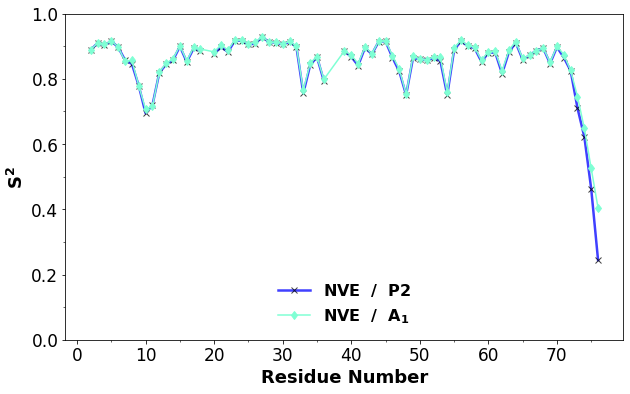

In [140]:
figS2UBQ = plt.figure(3287, figsize=(10,6))
axS2ubq = figS2UBQ.add_subplot(111)

#UBQ_NMRRelax_Exp[['RESID','S2_iso']].plot(x='RESID',y='S2_iso', color='k', style='-..',
#                                          label=r'$\mathbf{Experiment}$',
#                                          ax=axS2ubq, linewidth=2.5)

UBQ_OPTNVE_BS2.mean(axis=1).plot( style='-x', color='blue', markeredgecolor='k',
                                label = r'$\mathbf{NVE \ \ / \ \ P2}$',
                                ax = axS2ubq, linewidth=2.5, markersize=6.5, alpha=0.75)
NMRRelax_FitDF_UBQ_NVE.plot(x='Resname', y='C_a', color='aquamarine', ax=axS2ubq, marker='d', label=r'$\mathbf{NVE \ \ / \ \ A_{1}}$')

#UBQ_S2_CF02ps.mean(axis=1).plot(style='-s', color='orange', markeredgecolor='k',
#                                label = r'$\mathbf{NVT: \zeta = 0.2 \ \ ps^{-1}}$',
#                                ax = axS2ubq, linewidth=2.5, markersize=6.5, alpha=0.75)

#UBQ_S2_CF2ps.mean(axis=1).plot(style='-o',  color='green', markeredgecolor='k',
#                               label = r'$\mathbf{NVT: \zeta = 2 \ \ ps^{-1}}$',
#                               ax = axS2ubq, linewidth=2.5, markersize=6.5, alpha=0.75)

#UBQ_S2_CF20ps.mean(axis=1).plot(style='-d', color='red', markeredgecolor='k',
#                                label = r'$\mathbf{NVT: \zeta = 20 \ \ ps^{-1}}$', 
#                                ax = axS2ubq, linewidth=2.5, markersize=6.5, alpha=0.75)


axS2ubq.set_ylabel(r'$\mathbf{S^2}$', fontsize=18)
axS2ubq.set_xlabel(r'Residue Number', fontsize=18, weight='bold')
axS2ubq.tick_params(labelsize=17)
axS2ubq.set_xticks(np.arange(0,80,5), minor=True)
axS2ubq.set_yticks(np.arange(0,1.1,0.1), minor=True)
axS2ubq.legend(frameon=False, loc=8, prop={'size':16})

figS2UBQ.savefig('{}{}/Analysis/FigureS2_Ubiquitin_OrderParameters_Blocks_P2vsA1.png'.format(CorrFuncLoc2, 'Ubiquitin'),
                 dpi=600, bbox_inches='tight')

In [ ]:
UBQ_S2_CF20ps.mean(axis=1).reset_index().dtypes

### Figure S3: Methyl Order Parameters And Relaxation

In [44]:
def _read_MethylS2(atom_df, prot, ens, gamma = 'CF2ps'):
    
    """
    Function to read the order parameters functions calculated from cpptraj and python script 
    
    """
    tempcsv = pd.read_csv('{}/SCMethylOrderParameter_Direct.csv'.format(LocDF_NVE.loc['Run1',(prot, 'NVE')]),
                                                                         header=None)
    resS2df = pd.DataFrame(index=tempcsv.iloc[0], columns=RUNS)
    resS2df.index.name = 'SC_Pair'
    
    for R in RUNS:
            
        if ens == 'NVE':
            s2df = pd.read_csv('{}/SCMethylOrderParameter_Direct.csv'.format(LocDF_NVE.loc[R,(prot, ens)]),
                                                                         header=None).T
        elif ens =='NVT':
            s2df = pd.read_csv('{}/SCMethylOrderParameter_Direct.csv'.format(LocDF_NVT.loc[R,(prot, gamma)]),
                                   header=None).T
            
        s2df = s2df.rename(columns={0:'SC_Pair',1:r'$S^{2}$'})
        s2df[r'$S^{2}$'] = s2df[r'$S^{2}$'].astype('float64')
        resS2df.loc[:,R] = s2df[r'$S^{2}$'].values
            
    return resS2df

In [76]:
def _read_MethylS2_Blocks(locdf, atom_df, prot, ens, gamma = 'CF2ps'):
    
    """
    Function to read the order parameters functions calculated from cpptraj and python script 
    
    """
    tempcsv = pd.read_csv('{}/SCMethylOrderParameters_Block_1ns.csv'.format(LocDF_NVE.loc['Run1', (prot, 'NVE')]),
                          index_col=0)
    resS2df = pd.DataFrame(index=tempcsv.columns[1:], columns=RUNS)
    resS2df.index.name = 'SC_Pair'
    resS2df_STD = resS2df.copy()
    
    for R in RUNS:
            
        if ens == 'NVE':
            s2df = pd.read_csv('{}/SCMethylOrderParameters_Block_1ns.csv'.format(locdf.loc[R,(prot, ens)]),
                               index_col=0)
        elif ens =='NVT':
            s2df = pd.read_csv('{}/SCMethylOrderParameters_Block_1ns.csv'.format(locdf.loc[R,(prot, gamma)]),
                               index_col=0)
        
        resS2df.loc[s2df.columns[1:], R] = s2df.mean().iloc[1:]
        resS2df_STD.loc[s2df.columns[1:], R] = s2df.std().iloc[1:]
        
            
    return resS2df, resS2df_STD

In [48]:
LocDF_NVT.loc['Run1',('Ubiquitin', 'CF2ps')]

'E:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVT/CF2ps/Run1'

In [49]:
EXPMethylS2 = pd.read_csv('{}{}/Ubiquitin_MethylSC_S2Axis_Captured.csv'.format(CorrFuncLoc2, 'Ubiquitin'), 
                          header=None, names=['SC_Methyl',r'$S^{2}_{Exp}$'])

In [50]:
EXPMethylS2['RESNAME'] = EXPMethylS2['SC_Methyl'].apply(lambda scm : scm[0] )
EXPMethylS2['RESID'] = EXPMethylS2['SC_Methyl'].str.findall('([0-9]+)').apply(lambda resi: resi[0])
EXPMethylS2['METHYL_ATOMCode'] = EXPMethylS2['SC_Methyl'].str.findall('([A-Za-z]+)').apply(lambda atm: 'C{}'.format(atm[-1]).upper())
EXPMethylS2['METHYL_ATOMNum'] = EXPMethylS2['SC_Methyl'].str.findall('([A-Za-z]+)([0-9]+)').apply(lambda scid : scid[-1][1] if len(scid) > 1 else '')
EXPMethylS2['SCPair_key'] = (EXPMethylS2[['RESNAME', 'RESID', 'METHYL_ATOMCode', 'METHYL_ATOMNum']]
                             .apply(lambda scpair: '{}{}-{}{}'.format(scpair.RESNAME,scpair.RESID,scpair.METHYL_ATOMCode,scpair.METHYL_ATOMNum),axis=1))

In [51]:
pd.read_csv('{}/SCMethylOrderParameters_Block_1ns.csv'.format(LocDF_NVE.loc['Run1',('Ubiquitin', 'NVE')]), index_col=0)

,Blocks,ILE36_CG1C576,ILE30_CG1C484,ILE61_CG1C975,ILE23_CG1C366,ILE13_CG1C217,ILE44_CG1C712,ILE3_CG1C50,MET1_SDC14,ILE3_CBC43,...,LEU67_CGC1069,LEU67_CGC1073,LEU69_CGC1105,LEU69_CGC1109,VAL70_CBC1121,VAL70_CBC1125,LEU71_CGC1140,LEU71_CGC1144,LEU73_CGC1183,LEU73_CGC1187
0,2000,0.767135,0.907094,0.872040,0.677477,0.597620,0.479257,0.664258,0.698951,0.937781,...,0.377937,0.401144,0.859940,0.884395,0.822786,0.859418,0.441202,0.439797,0.279185,0.315101
1,4000,0.720648,0.883493,0.546715,0.793063,0.628466,0.349039,0.717774,0.696913,0.926227,...,0.272797,0.290873,0.873125,0.889372,0.868356,0.890557,0.307667,0.448959,0.174967,0.213182
2,6000,0.731806,0.899007,0.832934,0.781445,0.714822,0.729059,0.744902,0.627905,0.933510,...,0.372101,0.432502,0.837416,0.850058,0.856014,0.860862,0.509444,0.542392,0.179543,0.146479
3,8000,0.713011,0.902087,0.208321,0.811923,0.673896,0.139306,0.786163,0.464049,0.917639,...,0.258128,0.281247,0.545965,0.561449,0.489564,0.462739,0.631071,0.660550,0.532217,0.439386
4,10000,0.221807,0.902670,0.881552,0.816072,0.787981,0.582062,0.748121,0.502025,0.930337,...,0.247766,0.252125,0.403389,0.432163,0.866895,0.864166,0.352080,0.392430,0.208484,0.201962
5,12000,0.275267,0.903475,0.313757,0.839262,0.745340,0.422758,0.791922,0.553823,0.933734,...,0.800135,0.841638,0.362110,0.365552,0.910752,0.901241,0.746221,0.716513,0.528401,0.503467
6,14000,0.778527,0.895385,0.536448,0.832552,0.819448,0.428249,0.849381,0.368282,0.936236,...,0.814914,0.847877,0.563440,0.574024,0.442480,0.404908,0.361940,0.345616,0.258021,0.216973
7,16000,0.804457,0.908728,0.843105,0.873498,0.785865,0.121670,0.757052,0.475182,0.926955,...,0.814644,0.850903,0.306504,0.315228,0.872608,0.868086,0.820912,0.810332,0.444507,0.470281
8,18000,0.801709,0.918628,0.216072,0.767156,0.880114,0.444077,0.771832,0.506503,0.921076,...,0.823129,0.858035,0.235718,0.236190,0.398713,0.384567,0.815784,0.821459,0.457801,0.456968
9,20000,0.817601,0.918960,0.876238,0.859654,0.389614,0.527086,0.751303,0.501247,0.929655,...,0.450316,0.474633,0.278403,0.294170,0.093597,0.098661,0.822149,0.787664,0.502370,0.517077


In [65]:
pd.read_csv('{}/SCMethylOrderParameters_Block_1ns.csv'.format(LocDF_NVE.loc['Run1',('Ubiquitin', 'NVE')]), index_col=0)

,Blocks,ILE36_CG1C576,ILE30_CG1C484,ILE61_CG1C975,ILE23_CG1C366,ILE13_CG1C217,ILE44_CG1C712,ILE3_CG1C50,MET1_SDC14,ILE3_CBC43,...,LEU67_CGC1069,LEU67_CGC1073,LEU69_CGC1105,LEU69_CGC1109,VAL70_CBC1121,VAL70_CBC1125,LEU71_CGC1140,LEU71_CGC1144,LEU73_CGC1183,LEU73_CGC1187
0,2000,0.767135,0.907094,0.872040,0.677477,0.597620,0.479257,0.664258,0.698951,0.937781,...,0.377937,0.401144,0.859940,0.884395,0.822786,0.859418,0.441202,0.439797,0.279185,0.315101
1,4000,0.720648,0.883493,0.546715,0.793063,0.628466,0.349039,0.717774,0.696913,0.926227,...,0.272797,0.290873,0.873125,0.889372,0.868356,0.890557,0.307667,0.448959,0.174967,0.213182
2,6000,0.731806,0.899007,0.832934,0.781445,0.714822,0.729059,0.744902,0.627905,0.933510,...,0.372101,0.432502,0.837416,0.850058,0.856014,0.860862,0.509444,0.542392,0.179543,0.146479
3,8000,0.713011,0.902087,0.208321,0.811923,0.673896,0.139306,0.786163,0.464049,0.917639,...,0.258128,0.281247,0.545965,0.561449,0.489564,0.462739,0.631071,0.660550,0.532217,0.439386
4,10000,0.221807,0.902670,0.881552,0.816072,0.787981,0.582062,0.748121,0.502025,0.930337,...,0.247766,0.252125,0.403389,0.432163,0.866895,0.864166,0.352080,0.392430,0.208484,0.201962
5,12000,0.275267,0.903475,0.313757,0.839262,0.745340,0.422758,0.791922,0.553823,0.933734,...,0.800135,0.841638,0.362110,0.365552,0.910752,0.901241,0.746221,0.716513,0.528401,0.503467
6,14000,0.778527,0.895385,0.536448,0.832552,0.819448,0.428249,0.849381,0.368282,0.936236,...,0.814914,0.847877,0.563440,0.574024,0.442480,0.404908,0.361940,0.345616,0.258021,0.216973
7,16000,0.804457,0.908728,0.843105,0.873498,0.785865,0.121670,0.757052,0.475182,0.926955,...,0.814644,0.850903,0.306504,0.315228,0.872608,0.868086,0.820912,0.810332,0.444507,0.470281
8,18000,0.801709,0.918628,0.216072,0.767156,0.880114,0.444077,0.771832,0.506503,0.921076,...,0.823129,0.858035,0.235718,0.236190,0.398713,0.384567,0.815784,0.821459,0.457801,0.456968
9,20000,0.817601,0.918960,0.876238,0.859654,0.389614,0.527086,0.751303,0.501247,0.929655,...,0.450316,0.474633,0.278403,0.294170,0.093597,0.098661,0.822149,0.787664,0.502370,0.517077


In [53]:
EXPMethylS2

,SC_Methyl,$S^{2}_{Exp}$,RESNAME,RESID,METHYL_ATOMCode,METHYL_ATOMNum,SCPair_key
0,M1E,0.57,M,1,CE,,M1-CE
1,I3g2,0.84,I,3,CG,2,I3-CG2
2,V5g1,0.76,V,5,CG,1,V5-CG1
3,V5g2,0.79,V,5,CG,2,V5-CG2
4,L8d1,0.22,L,8,CD,1,L8-CD1
5,L8d2,0.20,L,8,CD,2,L8-CD2
6,I13g2,0.52,I,13,CG,2,I13-CG2
7,L15d1,0.43,L,15,CD,1,L15-CD1
8,L15d2,0.44,L,15,CD,2,L15-CD2
9,V17g2,0.79,V,17,CG,2,V17-CG2


In [54]:
UBQ_C13S2_NVE = _read_MethylS2(UBQNHatom_df, 'Ubiquitin', 'NVE', gamma='CF2ps')
UBQ_C13S2_CF2ps = _read_MethylS2(UBQNHatom_df, 'Ubiquitin', 'NVT', gamma='CF2ps')
UBQ_C13S2_CF02ps = _read_MethylS2(UBQNHatom_df, 'Ubiquitin', 'NVT', gamma='CF0-2ps')
UBQ_C13S2_CF20ps = _read_MethylS2(UBQNHatom_df, 'Ubiquitin', 'NVT', gamma='CF20ps')

FileNotFoundError: [Errno 2] File b'E:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE/Run1/SCMethylOrderParameter_Direct.csv' does not exist: b'E:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE/Run1/SCMethylOrderParameter_Direct.csv'

In [77]:
UBQ_C13S2_NVER1, UBQ_C13S2_NVER1_STD = _read_MethylS2_Blocks(LocDF_NVE, UBQNHatom_df, 'Ubiquitin', 'NVE', gamma='CF2ps')
UBQ_C13S2_NVER2, UBQ_C13S2_NVER2_STD = _read_MethylS2_Blocks(LocDF_NVE_R2, UBQNHatom_df, 'Ubiquitin', 'NVE', gamma='CF2ps')

UBQ_C13S2_CF02ps, UBQ_C13S2_CF02ps_STD = _read_MethylS2_Blocks(LocDF_NVT, UBQNHatom_df, 'Ubiquitin', 'NVT', gamma='CF0-2ps')
UBQ_C13S2_CF2ps, UBQ_C13S2_CF2ps_STD = _read_MethylS2_Blocks(LocDF_NVT, UBQNHatom_df, 'Ubiquitin', 'NVT', gamma='CF2ps')
UBQ_C13S2_CF20ps, UBQ_C13S2_CF20ps_STD = _read_MethylS2_Blocks(LocDF_NVT, UBQNHatom_df, 'Ubiquitin', 'NVT', gamma='CF20ps')


In [60]:
pd.read_csv('E:/Research/LangevinDynamics_RotationalDiffusion/Ubiquitin/PROD_NVE/Run1/SCMethylOrderParameters_Block_1ns.csv')

,Unnamed: 0,Blocks,ILE36_CG1C576,ILE30_CG1C484,ILE61_CG1C975,ILE23_CG1C366,ILE13_CG1C217,ILE44_CG1C712,ILE3_CG1C50,MET1_SDC14,...,LEU67_CGC1069,LEU67_CGC1073,LEU69_CGC1105,LEU69_CGC1109,VAL70_CBC1121,VAL70_CBC1125,LEU71_CGC1140,LEU71_CGC1144,LEU73_CGC1183,LEU73_CGC1187
0,0,2000,0.767135,0.907094,0.872040,0.677477,0.597620,0.479257,0.664258,0.698951,...,0.377937,0.401144,0.859940,0.884395,0.822786,0.859418,0.441202,0.439797,0.279185,0.315101
1,1,4000,0.720648,0.883493,0.546715,0.793063,0.628466,0.349039,0.717774,0.696913,...,0.272797,0.290873,0.873125,0.889372,0.868356,0.890557,0.307667,0.448959,0.174967,0.213182
2,2,6000,0.731806,0.899007,0.832934,0.781445,0.714822,0.729059,0.744902,0.627905,...,0.372101,0.432502,0.837416,0.850058,0.856014,0.860862,0.509444,0.542392,0.179543,0.146479
3,3,8000,0.713011,0.902087,0.208321,0.811923,0.673896,0.139306,0.786163,0.464049,...,0.258128,0.281247,0.545965,0.561449,0.489564,0.462739,0.631071,0.660550,0.532217,0.439386
4,4,10000,0.221807,0.902670,0.881552,0.816072,0.787981,0.582062,0.748121,0.502025,...,0.247766,0.252125,0.403389,0.432163,0.866895,0.864166,0.352080,0.392430,0.208484,0.201962
5,5,12000,0.275267,0.903475,0.313757,0.839262,0.745340,0.422758,0.791922,0.553823,...,0.800135,0.841638,0.362110,0.365552,0.910752,0.901241,0.746221,0.716513,0.528401,0.503467
6,6,14000,0.778527,0.895385,0.536448,0.832552,0.819448,0.428249,0.849381,0.368282,...,0.814914,0.847877,0.563440,0.574024,0.442480,0.404908,0.361940,0.345616,0.258021,0.216973
7,7,16000,0.804457,0.908728,0.843105,0.873498,0.785865,0.121670,0.757052,0.475182,...,0.814644,0.850903,0.306504,0.315228,0.872608,0.868086,0.820912,0.810332,0.444507,0.470281
8,8,18000,0.801709,0.918628,0.216072,0.767156,0.880114,0.444077,0.771832,0.506503,...,0.823129,0.858035,0.235718,0.236190,0.398713,0.384567,0.815784,0.821459,0.457801,0.456968
9,9,20000,0.817601,0.918960,0.876238,0.859654,0.389614,0.527086,0.751303,0.501247,...,0.450316,0.474633,0.278403,0.294170,0.093597,0.098661,0.822149,0.787664,0.502370,0.517077


In [78]:
UBQ_OPTNVE_C13S2  = UBQ_C13S2_NVER1.copy()
UBQ_OPTNVE_C13S2_STD = UBQ_C13S2_NVER1.copy()

UBQ_OPTNVE_C13S2['Run1'] = UBQ_C13S2_NVER1['Run3']
UBQ_OPTNVE_C13S2['Run2'] = UBQ_C13S2_NVER1['Run4']
UBQ_OPTNVE_C13S2['Run3'] = UBQ_C13S2_NVER2['Run2']
UBQ_OPTNVE_C13S2['Run4'] = UBQ_C13S2_NVER2['Run3']

UBQ_OPTNVE_C13S2_STD['Run1'] = UBQ_C13S2_NVER1_STD['Run1']
UBQ_OPTNVE_C13S2_STD['Run2'] = UBQ_C13S2_NVER1_STD['Run2']
UBQ_OPTNVE_C13S2_STD['Run3'] = UBQ_C13S2_NVER2_STD['Run1']
UBQ_OPTNVE_C13S2_STD['Run4'] = UBQ_C13S2_NVER2_STD['Run3']


In [79]:
UBQ_OPTNVE_C13S2.index.values

array(['ILE36_CG1C576', 'ILE30_CG1C484', 'ILE61_CG1C975', 'ILE23_CG1C366',
       'ILE13_CG1C217', 'ILE44_CG1C712', 'ILE3_CG1C50', 'MET1_SDC14',
       'ILE3_CBC43', 'VAL5_CBC82', 'VAL5_CBC86', 'THR7_CBC120',
       'LEU8_CGC137', 'LEU8_CGC141', 'THR9_CBC153', 'THR12_CBC196',
       'ILE13_CBC210', 'THR14_CBC229', 'LEU15_CGC246', 'LEU15_CGC250',
       'VAL17_CBC277', 'VAL17_CBC281', 'THR22_CBC345', 'ILE23_CBC359',
       'VAL26_CBC407', 'VAL26_CBC411', 'ALA28_CAC443', 'ILE30_CBC477',
       'ILE36_CBC569', 'LEU43_CGC689', 'LEU43_CGC693', 'ILE44_CBC705',
       'ALA46_CAC742', 'LEU50_CGC803', 'LEU50_CGC807', 'THR55_CBC877',
       'LEU56_CGC894', 'LEU56_CGC898', 'ILE61_CBC968', 'THR66_CBC1052',
       'LEU67_CGC1069', 'LEU67_CGC1073', 'LEU69_CGC1105', 'LEU69_CGC1109',
       'VAL70_CBC1121', 'VAL70_CBC1125', 'LEU71_CGC1140', 'LEU71_CGC1144',
       'LEU73_CGC1183', 'LEU73_CGC1187'], dtype=object)

In [80]:
SCPairDF = pd.Series(UBQ_OPTNVE_C13S2.index.values).str.split('_',expand=True)
SCPairDF['RESTYPE'] = SCPairDF[0].apply(lambda rr: str(rr[:3])).replace(Three2OneAA)
SCPairDF['RESID'] = SCPairDF[0].apply(lambda rr:int(rr[3:]))
SCPairDF['METHYL_Index'] = SCPairDF[1].str.findall('([0-9]+)').apply(lambda atm: atm[-1]).astype(int)
SCPairDF['METHYLNAME'] = (SCPairDF[['METHYL_Index','RESID']]
                      .apply(lambda rmethyl: str(UBQTop.atom(UBQTop.select('index {}'.format(rmethyl.METHYL_Index-1))[0])).split('-')[-1], axis=1))

In [81]:
SCPairDF['SCPair_key'] =  (SCPairDF[['RESTYPE', 'RESID', 'METHYLNAME']]
                           .apply(lambda scpair: '{}{}-{}'.format(scpair.RESTYPE,scpair.RESID,scpair.METHYLNAME),axis=1))

In [82]:
UBQ_OPTNVE_C13S2.index = SCPairDF['SCPair_key'].values
UBQ_C13S2_CF2ps.index = SCPairDF['SCPair_key'].values
UBQ_C13S2_CF02ps.index = SCPairDF['SCPair_key'].values
UBQ_C13S2_CF20ps.index = SCPairDF['SCPair_key'].values

In [84]:
UBQ_OPTNVE_C13S2.to_csv('{}{}/PROD_NVE/UBQ_SCMethyl_S2Axis_OptSimNVE.csv'.format(CorrFuncLoc2, 'Ubiquitin'))
UBQ_C13S2_CF2ps.to_csv('{}{}/PROD_NVT/CF2ps/UBQ_SCMethyl_S2Axis_NVT_CF2ps.csv'.format(CorrFuncLoc2, 'Ubiquitin'))

In [198]:
UBQ_OPTNVE_C13S2.index = SCPairDF['SCPair_key'].values
UBQ_C13S2_CF2ps.index = SCPairDF['SCPair_key'].values
UBQ_C13S2_CF02ps.index = SCPairDF['SCPair_key'].values
UBQ_C13S2_CF20ps.index = SCPairDF['SCPair_key'].values

,SC_Methyl,$S^{2}_{Exp}$,RESNAME,RESID,METHYL_ATOMCode,METHYL_ATOMNum,SCPair_key
0,M1E,0.57,M,1,CE,,M1-CE
1,I3g2,0.84,I,3,CG,2,I3-CG2
2,V5g1,0.76,V,5,CG,1,V5-CG1
3,V5g2,0.79,V,5,CG,2,V5-CG2
4,L8d1,0.22,L,8,CD,1,L8-CD1
5,L8d2,0.20,L,8,CD,2,L8-CD2
6,I13g2,0.52,I,13,CG,2,I13-CG2
7,L15d1,0.43,L,15,CD,1,L15-CD1
8,L15d2,0.44,L,15,CD,2,L15-CD2
9,V17g2,0.79,V,17,CG,2,V17-CG2


In [ ]:
EXPMethylS2.plot(x='SCPair_key', y = r'$S^{2}_{Exp}$')
UBQ_S2_NVE.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).plot()

In [ ]:
UBQ_C13S2_NVE.mean(axis=1).reset_index()

In [ ]:
EXPMethylS2['SCPair_key'].to_csv('{}{}/Ubiquitin_MethylNumberKey.csv'.format(CorrFuncLoc2, 'Ubiquitin'))

In [ ]:
UBQ_C13S2_CF2ps.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1)

In [ ]:
figC13S2UBQ = plt.figure(3289, figsize=(8, 6))
axC13S2ubq = figC13S2UBQ.add_subplot(111)

EXPMethylS2[['SCPair_key', r'$S^{2}_{Exp}$']].plot( y=r'$S^{2}_{Exp}$', color='k', style='-..',
                                          label=r'$\mathbf{Experiment}$',
                                          ax=axC13S2ubq, linewidth=2.5)

UBQ_OPTNVE_C13S2.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).reset_index().plot(y=0, style='-x', 
                                                                                    color='blue', markeredgecolor='k',
                                                                                    label = r'$\mathbf{NVE}$',
                                                                                    ax = axC13S2ubq,
                                                                                    linewidth=2.5, markersize=6.5,
                                                                                    alpha=0.75)

UBQ_C13S2_CF02ps.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).reset_index().plot(y=0, style='-s',
                                                                                       color='orange', markeredgecolor='k',
                                                                                       label = r'$\mathbf{NVT: \zeta = 0.2 \ \ ps^{-1}}$',
                                                                                       ax = axC13S2ubq, linewidth=2.5,
                                                                                       markersize=6.5, alpha=0.75)

UBQ_C13S2_CF2ps.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).reset_index().plot(y=0, style='-o',
                                                                                      color='green', markeredgecolor='k',
                                                                                      label = r'$\mathbf{NVT: \zeta = 2 \ \ ps^{-1}}$',
                                                                                      ax = axC13S2ubq, linewidth=2.5,
                                                                                      markersize=6.5, alpha=0.75)

UBQ_C13S2_CF20ps.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).reset_index().plot(y=0, style='-d',
                                                                                       color='red', markeredgecolor='k',
                                                                                       label = r'$\mathbf{NVT: \zeta = 20 \ \ ps^{-1}}$', 
                                                                                       ax = axC13S2ubq, linewidth=2.5,
                                                                                       markersize=6.5, alpha=0.75)


axC13S2ubq.set_ylabel(r'$\mathbf{S^2_{axis}}$', fontsize=18)
axC13S2ubq.set_xlabel(r'Methyl Number', fontsize=18, weight='bold')
axC13S2ubq.tick_params(labelsize=17)
axC13S2ubq.set_ylim(0.0,1.25)
#axC13S2ubq.set_xticks(np.arange(0,80,5), minor=True)
axC13S2ubq.set_yticks(np.arange(0.0, 1.2, 0.2))
axC13S2ubq.set_yticks(np.arange(0, 1.1, 0.1), minor=True)
## Split the legend
axC13hndls, axC13lbls = axC13S2ubq.get_legend_handles_labels()
nve_legend = axC13S2ubq.legend(axC13hndls[:2], axC13lbls[:2],
                               frameon=False, loc='upper left', prop={'size':14})
nvelgax = axC13S2ubq.add_artist(nve_legend)

axC13S2ubq.legend(axC13hndls[2:], axC13lbls[2:], frameon=False, loc='upper right', prop={'size':14})

figC13S2UBQ.savefig('{}{}/Analysis/FigureS3_Ubiquitin_SCMehtylOrderParameters_AllSims_CompareExp_Block1ns.png'.format(CorrFuncLoc2, 'Ubiquitin'),
                 dpi=600, bbox_inches='tight')

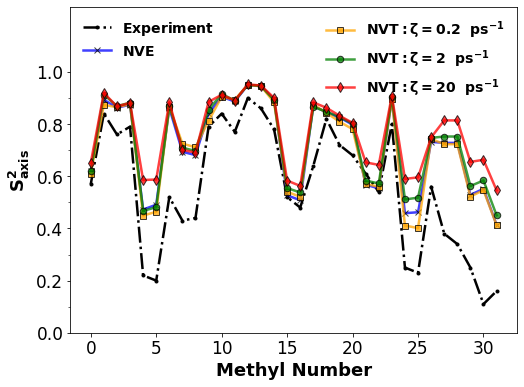

In [199]:
figC13S2UBQ = plt.figure(3289, figsize=(8, 6))
axC13S2ubq = figC13S2UBQ.add_subplot(111)

EXPMethylS2[['SCPair_key', r'$S^{2}_{Exp}$']].plot( y=r'$S^{2}_{Exp}$', color='k', style='-..',
                                          label=r'$\mathbf{Experiment}$',
                                          ax=axC13S2ubq, linewidth=2.5)

UBQ_OPTNVE_C13S2.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).reset_index().plot(y=0, style='-x', 
                                                                                    color='blue', markeredgecolor='k',
                                                                                    label = r'$\mathbf{NVE}$',
                                                                                    ax = axC13S2ubq,
                                                                                    linewidth=2.5, markersize=6.5,
                                                                                    alpha=0.75)

UBQ_C13S2_CF02ps.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).reset_index().plot(y=0, style='-s',
                                                                                       color='orange', markeredgecolor='k',
                                                                                       label = r'$\mathbf{NVT: \zeta = 0.2 \ \ ps^{-1}}$',
                                                                                       ax = axC13S2ubq, linewidth=2.5,
                                                                                       markersize=6.5, alpha=0.75)

UBQ_C13S2_CF2ps.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).reset_index().plot(y=0, style='-o',
                                                                                      color='green', markeredgecolor='k',
                                                                                      label = r'$\mathbf{NVT: \zeta = 2 \ \ ps^{-1}}$',
                                                                                      ax = axC13S2ubq, linewidth=2.5,
                                                                                      markersize=6.5, alpha=0.75)

UBQ_C13S2_CF20ps.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).reset_index().plot(y=0, style='-d',
                                                                                       color='red', markeredgecolor='k',
                                                                                       label = r'$\mathbf{NVT: \zeta = 20 \ \ ps^{-1}}$', 
                                                                                       ax = axC13S2ubq, linewidth=2.5,
                                                                                       markersize=6.5, alpha=0.75)


axC13S2ubq.set_ylabel(r'$\mathbf{S^2_{axis}}$', fontsize=18)
axC13S2ubq.set_xlabel(r'Methyl Number', fontsize=18, weight='bold')
axC13S2ubq.tick_params(labelsize=17)
axC13S2ubq.set_ylim(0.0,1.25)
#axC13S2ubq.set_xticks(np.arange(0,80,5), minor=True)
axC13S2ubq.set_yticks(np.arange(0.0, 1.2, 0.2))
axC13S2ubq.set_yticks(np.arange(0, 1.1, 0.1), minor=True)
## Split the legend
axC13hndls, axC13lbls = axC13S2ubq.get_legend_handles_labels()
nve_legend = axC13S2ubq.legend(axC13hndls[:2], axC13lbls[:2],
                               frameon=False, loc='upper left', prop={'size':14})
nvelgax = axC13S2ubq.add_artist(nve_legend)

axC13S2ubq.legend(axC13hndls[2:], axC13lbls[2:], frameon=False, loc='upper right', prop={'size':14})

figC13S2UBQ.savefig('{}{}/Analysis/FigureS3_Ubiquitin_SCMehtylOrderParameters_AllSims_CompareExp_Block1ns.png'.format(CorrFuncLoc2, 'Ubiquitin'),
                 dpi=600, bbox_inches='tight')

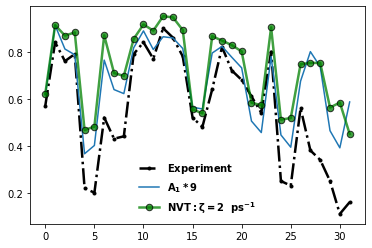

In [205]:
EXPMethylS2[['SCPair_key', r'$S^{2}_{Exp}$']].plot( y=r'$S^{2}_{Exp}$', color='k', style='-..',
                                          label=r'$\mathbf{Experiment}$', linewidth=2.5)
(NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp.dropna().reset_index(drop=True)['C_a']*9).plot(ax=plt.gca(),
                                                                                     label=r'$\mathbf{A_{1}*9}$')
UBQ_C13S2_CF2ps.loc[EXPMethylS2['SCPair_key'].values].mean(axis=1).reset_index().plot(y=0, style='-o',
                                                                                      color='green', markeredgecolor='k',
                                                                                      label = r'$\mathbf{NVT: \zeta = 2 \ \ ps^{-1}}$',
                                                                                      ax=plt.gca(), linewidth=2.5,
                                                                                      markersize=6.5, alpha=0.75)
plt.gca().legend(frameon=False)

### Supplemental Figure: N-H vs. 13C-H correlation functions

In [107]:
def func_exp_decay4(t, A, tau_a, B, tau_b ):
    return A*np.exp(-t/tau_a) + B*np.exp(-t/tau_b)

In [108]:
NHCorrDF_UBQ_NVT_CF2ps_AVE = pd.read_csv('{}Ubiquitin/Analysis/AverageFullCorrelationFunctions_NVT_2ps.csv'.format(CorrFuncLoc2), index_col=0)
NHCorrDF_UBQ_NVT_CF2ps_STD = pd.read_csv('{}Ubiquitin/Analysis/STDFullCorrelationFunctions_NVT_2ps.csv'.format(CorrFuncLoc2), index_col=0)
## Load Methyl Correlation Functions and Fits

C13HCorrDF_UBQ_NVT_Cf2ps_AVE = pd.read_csv('{}{}/PROD_NVT/CF2ps/METHYL_13CH_CorrFunctionsAverage.csv'.format(CorrFuncLoc2,'Ubiquitin'), index_col=0)
C13HCorrDF_UBQ_NVT_Cf2ps_STD = pd.read_csv('{}{}/PROD_NVT/CF2ps/METHYL_13CH_CorrFunctionsSTD.csv'.format(CorrFuncLoc2,'Ubiquitin'), index_col=0)


In [109]:
NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp = pd.read_csv('{}{}/PROD_NVT/CF2ps/NMRMethylRelaxation_FitDF_UBQ_2Exp_TS1_LnT.csv'.format(CorrFuncLoc2,'Ubiquitin'),
                                             index_col=0).dropna()

In [ ]:
NHCorrDF_UBQ_NVT_CF2ps_AVE

In [110]:
residue_numbers = NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp.dropna()['RESNUM'].values[1:]
residue_index = NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp.dropna()['RESNUM'].index[1:]
C13HCorrDF_UBQ_NVT_Cf2ps_AVE = C13HCorrDF_UBQ_NVT_Cf2ps_AVE.iloc[:, residue_index]
C13HCorrDF_UBQ_NVT_Cf2ps_AVE.columns = residue_numbers
C13HCorrDF_UBQ_NVT_Cf2ps_STD = C13HCorrDF_UBQ_NVT_Cf2ps_STD.iloc[:, residue_index]
C13HCorrDF_UBQ_NVT_Cf2ps_STD.columns = residue_numbers

In [115]:
residue_numbers

array([ 3,  5,  5,  8,  8, 13, 15, 15, 17, 23, 26, 28, 30, 36, 43, 43, 44,
       46, 50, 50, 56, 56, 61, 67, 67, 69, 70, 70, 71, 73, 73],
      dtype=int64)

In [ ]:
NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp['Resname'][NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp['RESNUM'] == rescol]

In [111]:
for corrfm, corrfstd in zip(C13HCorrDF_UBQ_NVT_Cf2ps_AVE[5].iteritems(), C13HCorrDF_UBQ_NVT_Cf2ps_STD[5].iteritems()):
    print(corrfm[1])

0.0000      1.000000
0.0005      0.798917
0.0010      0.793950
0.0015      0.786867
0.0020      0.780175
              ...   
249.9980   -0.002933
249.9985   -0.002908
249.9990   -0.002908
249.9995   -0.002908
250.0000   -0.002883
Name: 5, Length: 500001, dtype: float64
0.0000      1.000000
0.0005      0.783608
0.0010      0.776617
0.0015      0.768667
0.0020      0.761317
              ...   
249.9980    0.000108
249.9985    0.000117
249.9990    0.000150
249.9995    0.000133
250.0000    0.000142
Name: 5, Length: 500001, dtype: float64


In [125]:
METHYLResnames = UBQNHatom_df.set_index('RESID').loc[residue_numbers]['RESNAME'].apply(lambda rnm: '{}{}{}'.format(rnm[0],
                                                                                                                  rnm[1:3].lower(),
                                                                                                                  rnm[3:]))

In [126]:
METHYLResnames

RESID
3      Ile3
5      Val5
5      Val5
8      Leu8
8      Leu8
13    Ile13
15    Leu15
15    Leu15
17    Val17
23    Ile23
26    Val26
28    Ala28
30    Ile30
36    Ile36
43    Leu43
43    Leu43
44    Ile44
46    Ala46
50    Leu50
50    Leu50
56    Leu56
56    Leu56
61    Ile61
67    Leu67
67    Leu67
69    Leu69
70    Val70
70    Val70
71    Leu71
73    Leu73
73    Leu73
Name: RESNAME, dtype: object

In [130]:
## Plot Correlation functions
ResCorrFig = plt.figure(1, figsize=(8,6))

for rescol, C13resname in zip(residue_numbers, METHYLResnames):
    axCF = ResCorrFig.add_subplot(111)
    
    time_axis = NHCorrDF_UBQ_NVT_CF2ps_AVE.index.values
    NHCorrDF_UBQ_NVT_CF2ps_AVE[str(rescol)].plot(logx=True, ax = axCF,
                                                 label=r'$\mathbf{{N-H \ \ MD}}$', color='aquamarine')
    
    NHparams = NMRRelax_FitDF_UBQ_NVT_2ps[NMRRelax_FitDF_UBQ_NVT_2ps['Resname']==rescol][['C_a','tau_a','C_b','tau_b']].values.flatten()
    NHCorrModel = func_exp_decay4(time_axis, *NHparams)
    axCF.semilogx(time_axis, NHCorrModel, color='darkblue', linestyle='--', linewidth=2.0, label=r'$\mathbf{N-H \ \ Fit}$')
    
    axCF.fill_between(NHCorrDF_UBQ_NVT_CF2ps_AVE.index.values,
                      NHCorrDF_UBQ_NVT_CF2ps_AVE[str(rescol)].values-NHCorrDF_UBQ_NVT_CF2ps_STD[str(rescol)].values,
                      NHCorrDF_UBQ_NVT_CF2ps_AVE[str(rescol)].values+NHCorrDF_UBQ_NVT_CF2ps_STD[str(rescol)].values,
                      color='aquamarine', alpha=0.4)
    
    C13HNames = NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp['Resname'][NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp['RESNUM'] == rescol]
    if len(C13HCorrDF_UBQ_NVT_Cf2ps_AVE[rescol].shape) == 2:
        print(rescol)
        indx = 0
        for corrfm, corrfstd, lstl in zip(C13HCorrDF_UBQ_NVT_Cf2ps_AVE[rescol].iteritems(),
                                          C13HCorrDF_UBQ_NVT_Cf2ps_STD[rescol].iteritems(), [':','-.']):
            
            C13Hparams = NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp[NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp['RESNUM']==rescol][['C_a','tau_a','C_b','tau_b']].iloc[indx].values.flatten()
            C13CorrModel = func_exp_decay4(time_axis, *C13Hparams)
            
            corrfm[1].plot(logx=True, ax = axCF, color='orange', linestyle=lstl, linewidth=2,
                                     label=r'$\mathbf{{C13-H \ \ MD: {}}}$'.format(C13HNames.iloc[indx].split('-')[1]))
            axCF.fill_between(corrfm[1].index.values,
                              corrfm[1].values-corrfstd[1].values,
                              corrfm[1].values+corrfstd[1].values,
                              color='orange', alpha=0.4)
            axCF.semilogx(time_axis, C13CorrModel, color='darkred', linestyle=lstl,
                          linewidth=2.0, label=r'$\mathbf{C13-H \ \ Fit}$')
            axCF.text(1e-3, 0.325, C13resname, weight='bold', size=15, ha='center')            
            indx+=1
    else:
    #ResCorrDF_GB3_NVT_CF02ps[rcol].plot(logx=True, ax = axCF, label=r'$\mathbf{ NVT : \gamma = 0.2 \ \ ps^{-1}}$')
    
        C13Hparams = NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp[NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp['RESNUM']==rescol][['C_a','tau_a','C_b','tau_b']].values.flatten()
        C13CorrModel = func_exp_decay4(time_axis, *C13Hparams)
        
        C13HCorrDF_UBQ_NVT_Cf2ps_AVE[rescol].plot(logx=True, ax = axCF, color='orange',
                                     label=r'$\mathbf{C13-H \ \ MD}$')
        axCF.fill_between(C13HCorrDF_UBQ_NVT_Cf2ps_AVE.index.values,
                          C13HCorrDF_UBQ_NVT_Cf2ps_AVE[rescol].values-C13HCorrDF_UBQ_NVT_Cf2ps_STD[rescol].values,
                          C13HCorrDF_UBQ_NVT_Cf2ps_AVE[rescol].values+C13HCorrDF_UBQ_NVT_Cf2ps_STD[rescol].values,
                          color='orange', alpha=0.4)
        
        axCF.semilogx(time_axis, C13CorrModel, color='darkred', linestyle='--',
                      linewidth=2.0, label=r'$\mathbf{C13-H \ \ Fit}$')
        axCF.text(1e-3, 0.20, C13resname, weight='bold', size=15, ha='center')            
                         
    #ResCorrDF_GB3_NVT_CF20ps[rcol].plot(logx=True, ax = axCF, label=r'$\mathbf{ NVT : \gamma = 20 \ \ ps^{-1}}$')
    #axCF.set_title('Residue: {}'.format(rescol), fontsize=15, weight='bold')
    axCF.legend(loc=3, frameon=False, prop={'size':11})
    axCF.set_ylabel(r'$\mathbf{C(\tau)}$', fontsize=13)
    axCF.set_xlabel(r'$\mathbf{\tau \ \ (ns)}$',fontsize=13)
    axCF.tick_params(labelsize=15)
    axCF.set_ylim(-0.05, 1.0)
    axCF.set_xlim(2e-4,40)
    ResCorrFig.savefig('{}Ubiquitin/Analysis/ComparCorrelationFunctions/C13HCorrelationFunctions_WithCoupling_Res{}_NewFits.png'.format(CorrFuncLoc2, rescol) ,dpi=600, bbox_inches='tight')
    ResCorrFig.clear()
    

5
5
8
8
15
15
43
43
50
50
56
56
67
67
70
70
73
73


<Figure size 576x432 with 0 Axes>

In [ ]:
NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp[NMR13CH_FitDF_UBQ_NVT_2ps_FixTM_2exp['RESNUM']==rescol][['C_a','tau_a','C_b','tau_b']]

In [ ]:
rescol

In [ ]:
temps2 = pd.read_csv('{}/SCMethylOrderParameter_Direct.csv'.format(LocDF_NVE.loc['Run1',('Ubiquitin', 'NVE')]),
                                                                         header=None)
temps2T = temps2.T.rename(columns={0:'SC_Pair',1:'S2'})
temps2T['S2'] = temps2T['S2'].astype('float64')

In [ ]:
temps2T.plot.bar(x='SC_Pair', y='S2')

In [ ]:
temps2.iloc[0]

In [ ]:
for nt, R in enumerate([3,6,
                         2,1,4]):
    print(nt,R)